# Estudo Estatístico e Probabilístico de Dados Climáticos para Geração Fotovoltaica
---
## 1. Identificação do Grupo e Projeto
* **Instituição:** UFSJ - Universidade Federal de São João Del Rei
* **Curso:** Engenharia Elétrica
* **Disciplina:** Machine Learning Aplicado à Engenharia 
* **Docente:** Samir Angelo Milani Martins

### Integrantes:
* **André Reis Rodrigues Filho** - <span style="color:green"> Verde </span>
* **Igor Ferreira Rocha** - <span style="color:Blue"> Azul </span>
* **Yuri Lopes Gomes de Paulo** - <span style="color:Orange"> Laranja </span>

### Repositório e Fonte:
* **GitHub:** [Link para o repositório do projeto](https://github.com/IgorFerRoc/machine_learning_fotovoltaica.git)
* **Fonte de Dados:** [Portal de Dados do INMET](https://portal.inmet.gov.br/dadoshistoricos)

---

## 2. Contextualização e Justificativa do Projeto

**Objetivo Central:**
O presente trabalho consiste em uma análise estatística e probabilística de séries temporais climáticas para embasar o dimensionamento ótimo da potência instalada em sistemas fotovoltaicos. O escopo foca em mapear a previsibilidade de geração, mitigando as incertezas operacionais inerentes à intermitência e à variabilidade climática do recurso solar.

**Justificativa:**
A relevância deste estudo reside na necessidade de otimizar o planejamento e a operação do Sistema Elétrico de Potência (SEP). Ao modelar a viabilidade solar de uma região específica a partir de dados reais, o estudo desses dados fornece métricas confiáveis para avaliar áreas com alto potencial de expansão para novas usinas fotovoltaicas. Realizar esse mapeamento analítico é fundamental para garantir maior segurança energética, mitigar riscos de investimento e promover uma integração mais previsível de fontes renováveis à matriz elétrica nacional.

**Metodologia:**
O estudo foi desenvolvido por meio de rotinas computacionais na linguagem Python, estruturando um *pipeline* completo de processamento de dados sobre a série histórica de cinco anos coletada pelo INMET. A arquitetura da solução foi dividida nas seguintes frentes:
* **Saneamento de Dados:** Limpeza rigorosa da base bruta.
* **Análise Exploratória de Dados:** Condução de diagnósticos visuais e numéricos para identificar correlações, sazonalidades e perfis diários de radiação e temperatura.

## 3. Aquisição e Estratégia de Saneamento de Dados

A base de dados deste estudo provém do portal do **INMET (Instituto Nacional de Meteorologia)**, que foi coletada via download direto do site e é composta por séries históricas horárias. A seleção dos dados brutos priorizou a integridade física das grandezas que impactam diretamente a modelagem do recurso solar e a performance de sistemas fotovoltaicos no contexto do Sistema Elétrico de Potência (SEP).

### 3.1 Acervo Bruto do INMET
Os arquivos CSV originais fornecidos pelas estações automáticas do INMET possuem uma alta dimensionalidade, registrando 19 grandezas meteorológicas horárias distintas. O banco de dados bruto é composto pelas seguintes variáveis:

* `Data` e `Hora UTC`
* `PRECIPITAÇÃO TOTAL, HORÁRIO (mm)`
* `PRESSÃO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)`
* `PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)`
* `PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)`
* `RADIACAO GLOBAL (Kj/m²)`
* `TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)`
* `TEMPERATURA DO PONTO DE ORVALHO (°C)`
* `TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)`
* `TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)`
* `TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)`
* `TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)`
* `UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)`
* `UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)`
* `UMIDADE RELATIVA DO AR, HORARIA (%)`
* `VENTO, DIREÇÃO HORARIA (° (gr))`
* `VENTO, RAJADA MAXIMA (m/s)` e `VENTO, VELOCIDADE HORARIA (m/s)`

### 3.2 Dicionário de Variáveis e Relevância Física

As variáveis selecionadas para a realização do estudo e com o maior impacto matemático para o cálculo do potencial energético e das perdas térmicas operacionais:

| Variável Original | Descrição | Unidade | Justificativa Técnica |
| :--- | :--- | :--- | :--- |
| `Data` / `Hora UTC` | Timestamp | - | Base para análise sazonal e filtragem do período diurno. |
| `RADIACAO GLOBAL` | Irradiância Horizontal | kJ/m² | Variável primária para o cálculo de Horas de Sol Pleno (HSP). |
| `TEMP. AR - BULBO SECO` | Temperatura Ambiente | °C | Define a degradação de eficiência das células por calor. |
| `UMIDADE RELATIVA` | Umidade do Ar | % | Indicador de atenuação atmosférica e formação de nebulosidade. |
| `PRECIPITAÇÃO` | Volume de Chuva | mm | Avaliação da autolimpeza dos módulos e correlação com dias nublados. |

### 3.3 Padronizações e Transformações de Engenharia

Para elevar o nível de abstração dos dados brutos para métricas de interesse , as seguintes transformações foram implementadas:

* **Normalização Temporal:** Conversão dos horários de UTC para o horário local (Brasília).
* **Conversão Energética (HSP):** A radiação horária acumulada em $kJ/m^2$ foi convertida para **Horas de Sol Pleno (HSP)**. Esta transformação é fundamental para o dimensionamento fotovoltaico, pois condensa a energia diária em um valor de tempo equivalente sob irradiância de $1.000 W/m^2$.
* **Agregação Diária (Resampling):** A transição da escala horária para a diária foi realizada através de métodos de agregação diferenciados (Soma para Radiação/Chuva e Média para Temperatura/Umidade), reduzindo o volume operacional e focando na tendência de geração sustentada.

> **Justificativa da Amostragem:** A escolha por uma série histórica de **5 anos** justifica-se pela necessidade de capturar a variabilidade interanual do clima, permitindo que as métricas probabilísticas calculadas (P50, P90) possuam significância estatística para o planejamento energético de longo prazo.

## Bibliotecas Utilizadas 

In [100]:
import os
import re                             
import json
import shutil
import warnings  
import numpy as np
import pandas as pd
import seaborn as sns  
import plotly.express as px
import matplotlib.pyplot as plt                 
from pathlib import Path                  
from collections import defaultdict

## 4.0 Processamento dos Dados
<span style="color:Orange"> 
O tratamento de dados reais é uma etapa crítica. Bases governamentais e de sensores remotos, como as do INMET, frequentemente apresentam lacunas de medição ou registros de erro devido a falhas de calibração ou manutenção dos equipamentos.

Os principais desafios e etapas de filtragem enfrentados nesta base foram:

1. **Identificação de Valores Espúrios:** O INMET utiliza o valor padrão **-9999** para indicar dados ausentes ou falhos. Optou-se por substituir esses registros por valores nulos (`NaN`) com o intuito de evitar distorções nas análises estatísticas.
2. **Isolamento do Período de Geração (Diurno):** Como o foco é a geração fotovoltaica, a radiação solar noturna (nula) distorce as estatísticas de potencial energético. Criou-se um filtro para isolar o período de sol útil, selecionando a janela das 09:00 às 22:00 UTC (06:00 às 19:00 no horário de Brasília).
3. **Validação Diária:** Ao analisar os dados brutos, foi perceptível que muitas estações continham grandes lacunas, chegando a registrar meses inteiros sem informações. Para garantir representatividade, projetou-se um filtro que exige um mínimo de 10 registros horários válidos por dia, caso esse critério não fosse atendido, o dia era completamente descartado.
4. **Validação Mensal:** Com a remoção de vários dias inválidos na etapa anterior, surgiu a necessidade de realizar também uma filtragem em nível mensal. Estabeleceu-se como critério um mínimo de 21 dias válidos para que o mês fosse considerado na análise.
5. **Validação Anual:** Por fim, realizou-se uma análise de validade anual, já que muitos anos acabavam restando com poucos meses robustos. O critério definido para essa etapa exigiu que um ano tivesse pelo menos 8 meses inteiros validados para compor a base histórica.
6. **Seleção das Variáveis de Interesse:** Após as filtragens temporais, todos os parâmetros meteorológicos não pertinentes ao estudo foram removidos, mantendo-se no banco de dados final apenas as grandezas essenciais ressaltadas anteriormente.

Para a implementação computacional destas regras de negócio, desenvolveu-se um script em Python estruturado sobre a biblioteca Pandas. A lógica de filtragem opera iterativamente (ano a ano), garantindo eficiência de memória e rastreabilidade espacial.

Abaixo, detalha-se o funcionamento e as principais variáveis de controle do código:

* **Mapeamento e Injeção de Metadados (`colunas_map` e `metadados`):**
  O algoritmo inicializa um dicionário (`colunas_map`) para renomear colunas extensas para padrões sintéticos, otimizando a manipulação. Através da leitura via `open(arquivo, 'r')`, o código extrai as 10 primeiras linhas de cabeçalho para capturar a UF, o nome da Estação e o Código WMO, garantindo que o arquivo final filtrado possua um nome único e rastreável espacialmente.
* **Leitura Otimizada e Coerção de Nulos (`read_csv` e `na_values`):**
  Durante o carregamento do *DataFrame* (`df`), o parâmetro `usecols` assegura que apenas as colunas mapeadas sejam carregadas na RAM. Simultaneamente, o parâmetro `na_values=[-9999]` identifica os valores espúrios do INMET e os converte instantaneamente para `NaN`, resolvendo o passo 1 da metodologia logo na ingestão.
* **Formatação do Índice Temporal (`df['Hora']` e `df['Data']`):**
  A coluna de horas recebe um tratamento utilizando expressões regulares (`regex=True` com `\D`) para remover sufixos literais (como " UTC"), sendo convertida para número inteiro. Isso permite o fatiamento booleano exato da janela operacional: `(df['Hora'] >= 9) & (df['Hora'] <= 22)`.
* **Validação Lógica (O "Funil" de Qualidade):**
  * **Filtro Diário (`dias_validos`):** O código gera uma série booleana (`horas_positivas`) avaliando se a radiação é maior que zero. O agrupamento por dia (`groupby`) soma as horas operacionais. Apenas os dias com $\ge 10$ horas válidas compõem a variável `dias_validos`. O *DataFrame* é então reduzido para `df_bons`.
  * **Filtro Mensal (`meses_validos`):** O algoritmo compara os dias totais que existiam no mês original (`dias_originais_por_mes`) contra os dias que sobreviveram ao filtro diário (`dias_restantes_por_mes`). Se a perda for menor que 10 dias (ou seja, mantendo um saldo $\ge 21$ dias úteis), o mês é inserido na lista `meses_validos`.
  * **Filtro Anual:** Se o tamanho da lista `meses_validos` for menor que 8 (`len < 8`), o comando `continue` aborta o processamento daquela estação, descartando o ano incompleto.

Os dados que sobrevivem a este "funil" estatístico são exportados limpos e padronizados, prontos para a etapa de verificação de continuidade histórica. Abaixo encontra-se a rotina implementada:
Laranja </span>

In [101]:
CAMINHO_PRINCIPAL = Path(r"C:\Users\yuric\OneDrive\Documentos\Projeto Machine Learning\Dados") #Local Onde Está o Banco de Dados Baixado
anos = ['2021', '2022', '2023', '2024', '2025']

# Dicionário para renomear as colunas
colunas_map = {
    'Data': 'Data',
    'Hora UTC': 'Hora',
    'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'Precipitacao_mm',
    'RADIACAO GLOBAL (Kj/m²)': 'Radiacao_Kj_m2',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'Temp_Ar_C',
    'UMIDADE RELATIVA DO AR, HORARIA (%)': 'Umidade_Rel_%'
}

print("INICIANDO O PROCESSAMENTO\n")

#Loop Anual
for ano in anos:
    #Criação dos Caminhos
    pasta_origem = CAMINHO_PRINCIPAL / ano
    pasta_destino = CAMINHO_PRINCIPAL / f"{ano}_Filtrada"
    
    #Verificação de Existencia da Pasta de Origem
    if not pasta_origem.is_dir():
        print(f"Pasta {ano} não encontrada.")
        continue

    #Cria a Pasta de Destino Caso Ela Não Exista    
    pasta_destino.mkdir(parents=True, exist_ok=True)
    arquivos_csv = list(pasta_origem.glob('*.csv'))
    
    print(f"--- Processando Ano {ano}: {len(arquivos_csv)} arquivos encontrados ---")
    #Contador de Arquivos Salvos
    arquivos_salvos = 0
    
    #Loop dos Arquivos Anuais
    for arquivo_csv in arquivos_csv:
        try:
            #Extração das Informações Sobre as Estações
            metadados = {}
            #Abre o Arquivo CSV Atual em Modo Leitura
            with open(arquivo_csv, 'r', encoding='latin-1') as f:
                #Leitura das Primeiras 10 Linhas
                for _ in range(10):
                    linha = f.readline().strip().split(';')
                    #Verificação se a Linha Possui Pelo Menos 2 Elementos (Chave e Valor)
                    if len(linha) >= 2:
                        metadados[linha[0].replace(':', '').strip()] = linha[1].strip()

            #Busca Pelos Parametros no Dicionário metadados, Caso o Valor Não Seja Encontrado Assume-se um Valor Padrão            
            uf = metadados.get('UF', 'UF_NaoEncontrada')
            estacao = metadados.get('ESTACAO', 'Estacao_NaoEncontrada').replace(' ', '_')
            codigo = metadados.get('CODIGO (WMO)', 'Codigo_NaoEncontrado')
            novo_nome = f"{uf}-{estacao}-{codigo}-{ano}_Filtrada.csv"

            #Leitura e Limpeza Inicial dos Dados
            try:
                df = pd.read_csv(
                    arquivo_csv, sep=';', skiprows=8, encoding='latin-1', decimal=',',
                    usecols=lambda c: c in colunas_map.keys(), # Carrega Apenas as Colunas Desejadas
                    na_values=['-9999', -9999, -9999.0]        # Transforma os -9999 em NaN na Leitura
                )
            except ValueError:
                continue
            
            if df.empty:
                continue

            df = df.rename(columns=colunas_map)

            #Tratamento de Tipos e Filtragem de Horário
            
            df['Hora'] = df['Hora'].astype(str).str.replace(r'\D', '', regex=True).str.zfill(4).str[:2].astype(int) # Transforma a Coluna 'Hora' em String, Remove Tudo Que Não For Número, Garante 4 Dígitos, Pega os 2 primeiros e Converte Pra Inteiro
            df = df[(df['Hora'] >= 9) & (df['Hora'] <= 22)].copy() #Filtra as Horas Entre 09:00 e 22:00

            df['Data'] = pd.to_datetime(df['Data'], errors='coerce') # Converte a Coluna 'Data' Para o Formato Datetime do Pandas
            df['Mes'] = df['Data'].dt.month #Cria Uma Nova Coluna Mês
            df['Radiacao_Kj_m2'] = pd.to_numeric(df['Radiacao_Kj_m2'], errors='coerce') #Converte a Coluna 'Radiação_Kj_m2' Para o Formato Numérico
            
            #Aplicação das Regras de Qualidade
            dias_originais_por_mes = df.groupby('Mes')['Data'].nunique() #Contagem de Dias Unicos

            horas_positivas = df['Radiacao_Kj_m2'] > 0 #Realiza um Série Booleana das Horas Que Possuem Radiação
            horas_por_dia = horas_positivas.groupby(df['Data']).sum() #Soma o Numero de Horas Que Tiveram Radiação no Dia
            dias_validos = horas_por_dia[horas_por_dia >= 10].index #Identifica Se o Dia Possui Pelo Menos 10 Horas Válidas

            df_bons = df[df['Data'].isin(dias_validos)] #Mantem Apenas os Dias Contidos em 'dias_validos'
            
            dias_restantes_por_mes = df_bons.groupby('Mes')['Data'].nunique() #Identifica Quantos Dias Bons Teve no Mês
            
            #Lista de Mêses Válidos
            meses_validos = [
                mes for mes, dias_orig in dias_originais_por_mes.items()
                if (dias_orig - dias_restantes_por_mes.get(mes, 0)) < 10
            ]

            #Verifica se o Ano é Válido (Pelo Menos 8 Mêses Válidos)
            if len(meses_validos) < 8:
                continue 
            
            #Filtra o DF, Deixando Apenas os Dados Que Passaram no Teste de Qualidade
            df_final = df_bons[df_bons['Mes'].isin(meses_validos)].drop(columns=['Mes'])
            
            #Exportação
            if not df_final.empty:
                caminho_final = pasta_destino / novo_nome
                df_final.to_csv(caminho_final, sep=';', index=False, decimal=',')
                arquivos_salvos += 1
                
        except Exception as e:
            print(f" Erro no arquivo {arquivo_csv.name}: {e}")
            
    print(f"Concluído, {arquivos_salvos} arquivos possuíam dados válidos e foram salvos.\n")

print("PROCESSO FINALIZADO")

INICIANDO O PROCESSAMENTO

--- Processando Ano 2021: 588 arquivos encontrados ---
Concluído, 297 arquivos possuíam dados válidos e foram salvos.

--- Processando Ano 2022: 567 arquivos encontrados ---
Concluído, 336 arquivos possuíam dados válidos e foram salvos.

--- Processando Ano 2023: 567 arquivos encontrados ---
Concluído, 452 arquivos possuíam dados válidos e foram salvos.

--- Processando Ano 2024: 565 arquivos encontrados ---
Concluído, 434 arquivos possuíam dados válidos e foram salvos.

--- Processando Ano 2025: 594 arquivos encontrados ---
Concluído, 362 arquivos possuíam dados válidos e foram salvos.

PROCESSO FINALIZADO


### 4.1 Filtragem das Estações Meteorológicas 
<span style="color:Orange">
Após a limpeza intrínseca dos dados, foi necessário garantir a robustez longitudinal da base. Para estudos de viabilidade fotovoltaica e previsão de geração, é fundamental analisar uma série histórica contínua, capaz de capturar variações interanuais de radiação e temperatura.

Para isso, desenvolveu-se uma rotina de verificação e consolidação espacial com as seguintes premissas operacionais:

1. **Critério de Aprovação Exigente:** A estação meteorológica só é considerada válida para a modelagem final se possuir dados aprovados para todos os 5 anos da janela de pesquisa (2021 a 2025).
2. **Organização Automatizada de Diretórios:** As estações aprovadas tiveram seus arquivos anuais agrupados em pastas exclusivas por localidade, facilitando o consumo desses dados por futuros algoritmos de aprendizado de máquina.
3. **Auditoria e Rastreabilidade:** Estações que não atenderam ao critério de 5 anos foram descartadas da base principal e documentadas em um log automático (`Relatorio_Arquivos_Reprovados.txt`), que mapeia exatamente quais anos sobreviveram aos filtros iniciais para cada localidade reprovada.

Para operacionalizar esses critérios temporais e espaciais sem comprometer o desempenho computacional, o script foi projetado utilizando mapeamento de dados estruturado e manipulação de diretórios. 

Abaixo, detalha-se o funcionamento dinâmico e as principais variáveis estruturais do código:

* **Estruturação de Dados Dinâmica (`defaultdict(list)` e `estacoes_agrupadas`):**
  Em vez de executar buscas repetitivas (processamento ineficiente), o código utiliza uma estrutura de dados de dicionário avançada do pacote `collections`. Ao varrer as pastas de 2021 a 2025, o algoritmo recorta a raiz do nome do arquivo para formar a `identidade` da estação (ex: `MG-SAO_JOAO_DEL_REI-A514`). Esta identidade atua como uma chave (*key*), e todos os arquivos referentes a ela são instantaneamente anexados a uma lista (*value*).
* **O "Gatilho" de Continuidade Temporal (`len(arquivos) == TOTAL_ANOS`):**
  A variável `TOTAL_ANOS` (parametrizada como 5) é o motor lógico da filtragem. O código itera sobre o dicionário construído na etapa anterior e realiza uma verificação de cardinalidade: se a lista de arquivos atrelada a uma estação possuir um comprimento exatamente igual a 5, ela é considerada apta e segue para o agrupamento.
* **Migração e Preservação de Metadados (`shutil.copy2`):**
  Para as estações aprovadas no gatilho temporal, o sistema instancializa uma pasta própria e realiza a migração dos dados utilizando a biblioteca `shutil`. A escolha específica do método `copy2` (em detrimento de comandos de cópia comuns) é vital na engenharia de dados, pois além de replicar o conteúdo, ele preserva as *timestamps* originais e metadados do sistema (data de criação e última modificação), mantendo a fidelidade do arquivo baixado do INMET.
* **Sistema de Auditoria e Log de Exclusão (`caminho_relatorio`):**
  A ramificação condicional `else` captura todas as instâncias que falharam no teste temporal (possuindo de 1 a 4 arquivos). O algoritmo não descarta os dados silenciosamente; ele entra em modo de escrita (`'w'`) e formaliza um relatório em `.txt`. O script percorre a lista da estação reprovada, ordena alfabeticamente os arquivos remanescentes e imprime um log detalhado, conferindo total transparência sobre as lacunas climáticas encontradas no território nacional.

Abaixo encontra-se o código utilizado nesta etapa de consolidação espacial:
</span>

In [102]:
TOTAL_ANOS = len(anos)

#Criação dos Caminhos
pasta_mestre = CAMINHO_PRINCIPAL / f"Arquivos {TOTAL_ANOS} anos Filtrados"
pasta_mestre.mkdir(parents=True, exist_ok=True)
caminho_relatorio = pasta_mestre / "Relatorio_Arquivos_Reprovados.txt"

print(f"Iniciando a verificação de continuidade histórica ({TOTAL_ANOS} anos)...\n")

# Cria o Dicionário Especial de Listas.
estacoes_agrupadas = defaultdict(list)

#Loop Anual
for ano in anos:
    pasta_ano = CAMINHO_PRINCIPAL / f"{ano}_Filtrada"
    
    #Ferificação da Existencia da Pasta
    if not pasta_ano.is_dir():
        print(f"[AVISO] Pasta {pasta_ano.name} não encontrada.")
        continue

    # Busca Todos os Arquivos CSV na Pasta     
    for arquivo in pasta_ano.glob('*.csv'):
        identidade = arquivo.name.replace(f"-{ano}_Filtrada.csv", "") # Remove o Sufixo do Ano e a Palavra '_Filtrada.csv' do Nome do Arquivo
        estacoes_agrupadas[identidade].append(arquivo) #{ 'Nome_da_Estacao': [arquivo_2021, arquivo_2022, ...] }

#Variaveis para Contabilização das Estações
estacoes_aprovadas = 0
estacoes_reprovadas = 0

print("Verificando estações e gerando relatórios...\n")

# Abre o Arquivo de Texto de Relatório em Modo Escrita ('w')
with open(caminho_relatorio, 'w', encoding='utf-8') as relatorio:
    relatorio.write(f"=========================================================\n"
                    f"   RELATÓRIO DE ESTAÇÕES REPROVADAS (DADOS INCOMPLETOS)\n"
                    f"=========================================================\n\n"
                    f"Estações que não possuem dados em todos os {TOTAL_ANOS} anos.\n\n")

    # Loop das Estações e dos aquivos nas Estações
    for identidade, arquivos in estacoes_agrupadas.items():
        
        # Verifica se a Estação Possui Arquivos de Todos os Anos e Cria uma Subpasta Para a estação
        if len(arquivos) == TOTAL_ANOS:
            pasta_destino = pasta_mestre / f"{identidade}-Filtrada"
            pasta_destino.mkdir(exist_ok=True)
            
            # Copia Cada Arquivo da Estação Aprovada Para a Nova Subpasta
            for arq in arquivos:
                shutil.copy2(arq, pasta_destino / arq.name)
                
            estacoes_aprovadas += 1

        # Organiza Todas as Estações Que Não Possuem Todos os Anos em Ordem Alfabética e Inserem no Arquivo 'Relatorio_Arquivos_Reprovados'    
        else:
            estacoes_reprovadas += 1
            nomes_arquivos = sorted(arq.name for arq in arquivos)
            texto_arquivos = "".join(f"      - {nome}\n" for nome in nomes_arquivos)
            relatorio.write(f"ESTAÇÃO: {identidade}\n"
                            f" -> Status: Apenas {len(arquivos)} de {TOTAL_ANOS} anos encontrados.\n"
                            f" -> Arquivos presentes:\n"
                            f"{texto_arquivos}"
                            f"--------------------------------------------------\n\n")

print("--- PROCESSO FINALIZADO ---")
print(f"Total de estações processadas: {len(estacoes_agrupadas)}")
print(f"APROVADAS (copiadas): {estacoes_aprovadas}")
print(f"REPROVADAS (no log):  {estacoes_reprovadas}")
print(f"\nVerifique a pasta '{pasta_mestre.name}' para os resultados!")

Iniciando a verificação de continuidade histórica (5 anos)...

Verificando estações e gerando relatórios...

--- PROCESSO FINALIZADO ---
Total de estações processadas: 540
APROVADAS (copiadas): 155
REPROVADAS (no log):  385

Verifique a pasta 'Arquivos 5 anos Filtrados' para os resultados!


>**Resultado do Agrupamento:**
A rotina iterou sobre um total de **540** estações inicialmente disponíveis. Dessas, **155** estações atenderam a todos os rigorosos critérios de qualidade temporal e possuem uma série de 5 anos ininterruptos, formando a base de dados definitiva para o estudo estatístico e probabilístico. As demais **385** estações foram descartadas por inconsistência histórica.

### 4.2 Extração de Coordenadas e Mapeamento Espacial
<span style="color:Orange">
Com as estações validadas e organizadas em seus respectivos diretórios, o passo seguinte consistiu no georreferenciamento da base. Os arquivos brutos do INMET contêm, em suas linhas iniciais (cabeçalho), os metadados da estação, incluindo Latitude e Longitude. 

Para evitar o processamento desnecessário de gigabytes de dados apenas para buscar coordenadas, desenvolveu-se um algoritmo otimizado que:
1. Realiza o cruzamento das estações validadas (aprovadas no critério de 5 anos) com o banco de dados original.
2. Lê estritamente as 10 primeiras linhas de cada arquivo para extrair as chaves geográficas.
3. Tratou e consolidou essas informações em um novo banco de dados (`Coordenadas_Cidades.csv`).

Para isso, o script implementou técnicas de fatiamento de *strings* e leitura parcial de *DataFrames*. 

Abaixo, detalham-se as principais variáveis e o fluxo lógico do processo:

* **Mapeamento de Alvos (`estacoes_alvo`):**
  O algoritmo inicializa varrendo as pastas das estações já validadas. Utilizando o método `.split('-')`, o código "fatia" o nome do diretório para isolar o código WMO da estação e reconstruir o nome limpo da cidade (removendo *underscores* e prefixos). Estes dados são armazenados na lista de dicionários `estacoes_alvo`, que serve como o guia de busca para a próxima etapa.
* **Leitura Parcial Otimizada (`nrows=10` e `df_meta`):**
  Esta é a principal otimização computacional do script. Ao localizar o arquivo bruto correspondente à estação alvo, a função `pd.read_csv` é acionada com o parâmetro restritivo `nrows=10` e `header=None`. Isso força o Pandas a carregar apenas o cabeçalho do arquivo na memória RAM, ignorando as milhares de linhas da série temporal histórica e reduzindo o tempo de processamento de minutos para frações de segundo.
* **Busca e Tratamento Numérico (`lat_val` e `lon_val`):**
  Com o mini-*DataFrame* (`df_meta`) instanciado, o código utiliza métodos de localização textual vetorial (`str.contains("LATITUDE")` e `"LONGITUDE"`) para encontrar a linha exata da coordenada. Em seguida, aplica-se uma substituição de caracteres (`replace(',', '.')`) para converter o padrão numérico brasileiro para o padrão internacional de ponto flutuante, essencial para a plotagem geoespacial posterior.
* **Auditoria de Conformidade (`estacoes_encontradas` e Conjuntos):**
  Para garantir que nenhuma estação ficou sem georreferenciamento, o script utiliza a estrutura de dados de Conjuntos Matemáticos (`set`). Ao final da extração, realiza-se uma operação de diferença (`todos_codigos - estacoes_encontradas`). Caso o resultado acuse a existência de `codigos_faltantes`, o algoritmo gera automaticamente um log de auditoria (`Estacoes_Nao_Encontradas.txt`), garantindo total controle sobre a integridade do mapeamento.

Abaixo, apresentamos o código de extração geométrica e tratamento de metadados utilizado nesta etapa:
</span>

In [103]:
caminho_pastas_origem = Path(r"C:\Users\yuric\OneDrive\Documentos\Projeto Machine Learning\Dados\Arquivos 5 anos Filtrados") #Local Onde Está a Pasta Arquivos 5 anos Filtrados Criada no Código Anterior
caminho_arquivos_inmet = Path(r"C:\Users\yuric\OneDrive\Documentos\Projeto Machine Learning\Dados\2021") #Local Onde Está a Pasta com os Dados Brutos de 2021

estacoes_alvo = []

 # Verifica se a Pasta Existe
if caminho_pastas_origem.exists():
    # Loop dos Arquivos Nas Pastas
    for item in caminho_pastas_origem.iterdir():
        # Verifica se o Arquivo é Uma Pasta
        if item.is_dir():
            partes = item.name.split('-')
            
            # Verifica se o Nome Tem Pelo Menos 4 Partes e se a Última Parte é a Palavra "Filtrada"
            if len(partes) >= 4 and partes[-1].lower() == "filtrada":
                codigo_estacao = partes[-2].upper()
                
                # Junta Tudo que Está Entre a UF e o Código para Formar o Nome da Cidade
                nome_bruto = "-".join(partes[1:-2])
                nome_exibicao = nome_bruto.replace("_", " ").strip(" -") # Limpa o Nome da Cidade
                # Adiciona os Dados das Estações em Um Dicionário
                estacoes_alvo.append({
                    "codigo": codigo_estacao,
                    "cidade_exibicao": nome_exibicao,
                    "pasta_original": item.name
                })

dados_finais = []
estacoes_encontradas = set() # Cria um Conjunto Vazio Para Armazenar os Códigos das estações

# Verifica se a Pasta Existe
if caminho_arquivos_inmet.exists():
    arquivos_csv = list(caminho_arquivos_inmet.glob("*.csv"))
    
    # Lopp das Estações
    for estacao in estacoes_alvo:
        codigo = estacao["codigo"]
        
        # Loop dos Arquivos dentro da Pasta
        for arquivo in arquivos_csv:
            arquivo_nome_maiusculo = arquivo.name.upper() # Transforma o Nome do Arquivo Bruto Todo em Maiúsculo para Não Ter Erro de Letrização
            
            #Procura Apenas Pelo Código
            if f"_{codigo}_" in arquivo_nome_maiusculo:
                try:
                    # Lê APENAS as 10 Primeiras Linhas do CSV
                    df_meta = pd.read_csv(arquivo, sep=';', encoding='latin-1', nrows=10, header=None, on_bad_lines='skip')
                    coluna_chaves = df_meta[0].astype(str).str.upper()
                    
                    # Localiza na Coluna 0 Onde Está Escrito "LATITUDE" e "LONGITUDE" e Pega o Valor Correspondente na Coluna 1
                    lat_val = df_meta.loc[coluna_chaves.str.contains("LATITUDE"), 1].values
                    lon_val = df_meta.loc[coluna_chaves.str.contains("LONGITUDE"), 1].values
                    
                    # Verifica Se Encontrou Ambos
                    if len(lat_val) > 0 and len(lon_val) > 0:
                        # Extrai o Valor e Troca a Vírgula por Ponto
                        lat = str(lat_val[0]).replace(',', '.').strip()
                        lon = str(lon_val[0]).replace(',', '.').strip()
                        
                        # Salva o Pacote Completo na Lista de Dados Finais
                        dados_finais.append({
                            "Estacao": codigo,
                            "Cidade": estacao["cidade_exibicao"],
                            "Latitude": lat,
                            "Longitude": lon
                        })
                        estacoes_encontradas.add(codigo) 
                except Exception as e:
                    pass
                
                break

#Geração do Arquivo
if dados_finais:
    df_resultado = pd.DataFrame(dados_finais)
    df_resultado.to_csv("Coordenadas_Cidades.csv", index=False, encoding="utf-8")
    
    #Verifica Quais Faltaram Pelo Código da Estação
    todos_codigos = {e["codigo"] for e in estacoes_alvo}
    codigos_faltantes = todos_codigos - estacoes_encontradas # Verifica Se Todas as Estações Foram Encontradas
    
    # Se Faltou Alguma Estação Abre um Arquivo de Texto para Criar um Relatório das Faltantes
    if codigos_faltantes:
        with open("Estacoes_Nao_Encontradas.txt", "w", encoding="utf-8") as f_out:
            f_out.write("Estações sem dados no INMET:\n\n")
            for estacao in estacoes_alvo:
                if estacao["codigo"] in codigos_faltantes:
                    f_out.write(f"Código: {estacao['codigo']} | Pasta: {estacao['pasta_original']}\n")
    
    print(f"-> Arquivo 'Coordenadas_Cidades.csv' gerado com sucesso!")
    if codigos_faltantes:
        print(f"-> Arquivo 'Estacoes_Nao_Encontradas.txt' gerado.")
else:
    print("Nenhuma correspondência encontrada.")

-> Arquivo 'Coordenadas_Cidades.csv' gerado com sucesso!


><span style="color:Orange">Com as coordenadas espaciais devidamente isoladas e formatadas, utilizamos a biblioteca `Plotly Express` para renderizar a distribuição geográfica das estações meteorológicas válidas. 
A plotagem interativa permite uma avaliação visual da abrangência do estudo, ajudando a identificar a densidade de cobertura dos sensores ao longo do território e possíveis gargalos regionais de informação climática.Laranja </span>

In [104]:
# Carrega os dados
df = pd.read_csv("Coordenadas_Cidades.csv")
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')
df = df.dropna(subset=['Latitude', 'Longitude'])

# Cria o mapa
fig = px.scatter_map(
    df, lat="Latitude", lon="Longitude",
    hover_name="Cidade", hover_data=["Estacao"],
    color_discrete_sequence=["#2A09E5"], zoom=2.5,
    center={"lat": -14.2350, "lon": -51.9253}
)

fig.update_layout(
    mapbox_style="carto-positron",
    margin={"r":0,"t":40,"l":0,"b":0},
    title_text="Distribuição das Estações",
    title_x=0.5
)

fig.show()

<span style="color:Orange">
**Análise da Distribuição Espacial:**
A partir da visualização do mapa gerado, constata-se que a distribuição espacial das estações meteorológicas é fortemente assimétrica ao longo do território nacional. Podemos destacar três pontos principais:

1. **Alta Concentração no Centro-Sul e Litoral:** Há uma densidade expressiva de pontos de coleta nas regiões Sudeste, Sul e em grande parte do Centro-Oeste, além da faixa litorânea do Nordeste. Isso reflete o padrão histórico de infraestrutura, densidade demográfica e atividade econômica do país.
2. **Escassez e "Vazios" de Dados:** Em contrapartida, a região Norte (bacia amazônica) e vastas áreas do interior do Nordeste apresentam uma cobertura extremamente esparsa. Muitas estações nessas regiões provavelmente foram eliminadas nas etapas anteriores por não atingirem o critério de 5 anos ininterruptos de operação.
3. **Impacto na Modelagem:** Para os objetivos deste estudo em energia fotovoltaica, essa distribuição indica que os modelos estatísticos e algoritmos preditivos terão alta confiabilidade e representatividade para a porção Centro-Sul do Brasil. Contudo, generalizações e previsões de geração para a região Norte deverão ser interpretadas com cautela, dada a baixa densidade de dados validados nessa área.
</span>

## 5.0 Análise Estatística

Com a base de dados validada, tratada e consolidada, iniciamos a etapa de diagnóstico estatístico das variáveis climáticas. Para sistemas fotovoltaicos, a simples observação de médias anuais brutas não é suficiente; é essencial compreender a variabilidade, a dispersão dos dados e os padrões de ocorrência do recurso solar.

Nesta etapa, utilizamos métricas de estatística descritiva (como média, mediana e desvio padrão) aliadas à exploração visual. Como o potencial de geração e a eficiência térmica dos painéis sofrem forte influência das estações do ano, nossa primeira frente de análise foi focada no perfil sazonal das localidades, investigando o comportamento da radiação global e da temperatura mês a mês ao longo da série histórica.

### 5.1 Analise Estatisticos Ano
<span style="color:Blue">
Para viabilizar a análise estatística sazonal e preparar a base para futuros algoritmos de *Machine Learning*, foi necessário reduzir a granularidade dos dados brutos. O processamento direto de dados horários (24 observações por dia) introduz ruídos de curto prazo que podem ofuscar tendências climáticas de longo prazo. Portanto, implementou-se uma rotina de agregação para converter o histórico horário em um formato diário consolidado.

As principais etapas matemáticas e de transformação aplicadas foram:

1. **Tipagem e Padronização Cronológica:**
   * **Tratamento de Strings:** Remoção de sufixos textuais (como " UTC") e de formatações inconsistentes nas colunas de hora, permitindo a correta indexação do `DataFrame` no formato `datetime`.
   * **Coerção Numérica:** Conversão forçada das variáveis físicas (Radiação e Precipitação) para o tipo ponto flutuante (`float`). Valores corrompidos ou não numéricos foram mapeados para nulos (`NaN`) através do parâmetro `errors='coerce'`, garantindo a estabilidade matemática das iterações.

2. **Agregação Diária e Funções Estatísticas (`resample`):**
   A compressão de 24 linhas horárias para 1 linha diária exigiu a aplicação de funções matemáticas específicas, coerentes com a natureza de cada grandeza:
   * **Acúmulo Diário (Soma):** Aplicado à Precipitação e à Radiação Global, obtendo o volume total de chuva e a energia total incidente naquele dia.
   * **Tendência Central (Média):** Aplicado à Temperatura e Umidade Relativa, representando o comportamento térmico médio diário.
   * **Extremos Térmicos (Máximo e Mínimo):** Captura dos picos de temperatura, essenciais para o cálculo da amplitude térmica e avaliação de estresse operacional dos módulos fotovoltaicos.
   * **Horas de Sol Pleno (HSP):** Implementação de conversão matemática para transformar a radiação acumulada na métrica de HSP, um parâmetro padronizado e indispensável para o dimensionamento solar.

3. **Engenharia de Atributos Geotemporais:**
   * **Decomposição Sazonal:** Separação do índice temporal em colunas autônomas (Ano, Mês e Dia). Essa estruturação explicita as componentes sazonais, otimizando o reconhecimento de padrões em modelos preditivos.
   * **Rastreabilidade Geográfica:** Injeção sistemática das colunas de Estado (UF) e Cidade em cada registro diário. Isso permitiu a compilação de múltiplas estações sem a perda da identidade espacial dos dados.

4. **Consolidação e Exportação:**
   * Os dados processados de todas as cidades foram concatenados em um único arquivo mestre (`Dados-Diarios-Estacoes.csv`). A exportação utilizou o padrão regional brasileiro (`sep=';'`, `decimal=','`) para garantir a interoperabilidade imediata com softwares de análise e planilhas eletrônicas.

**Síntese das Operações Otimizadas:**

| Operação (Pandas) | Benefício Técnico para o Projeto |
| :--- | :--- |
| `.resample('D')` | Reduz o volume de dados em um fator de 13x e mitiga a variância de curtíssimo prazo. |
| `errors='coerce'` | Confere resiliência ao algoritmo, isolando anomalias textuais sem interromper o processamento. |
| `.reset_index()` | Transforma o eixo cronológico temporal em uma variável tabular explícita e manipulável. |
| `.round(2)` | Mantém a leveza computacional do arquivo consolidado, mantendo a precisão científica (duas casas decimais). |

In [105]:
# Suprime avisos de inferência de formato de data para manter o console focado apenas no progresso
warnings.filterwarnings("ignore", message="Could not infer format")

# 1. CONFIGURAÇÃO DE CAMINHOS
# Define onde estão as pastas das estações (cada pasta deve conter os 5 anos de CSVs)
diretorio_raiz = Path(r"C:\Users\yuric\OneDrive\Documentos\Projeto Machine Learning\Dados\Arquivos 5 anos Filtrados")

# Nome do arquivo final que será gerado com as métricas mensais compiladas
arquivo_saida = Path("Estatísticas-Estações.csv")

# 2. PROCESSAMENTO MULTI-ESTAÇÕES
lista_consolidada = []

# Varre todas as subpastas do diretório raiz (cada pasta representa uma estação meteorológica)
for pasta in diretorio_raiz.iterdir():
    if not pasta.is_dir():
        continue
    
    # Extrai metadados (UF e Cidade) baseando-se na nomenclatura padrão das suas pastas
    partes_nome = pasta.name.split('-')
    uf = partes_nome[0]
    cidade = partes_nome[1]

    # Localiza todos os arquivos CSV dentro da pasta da estação atual
    arquivos_csv = list(pasta.glob("*.csv"))
    if not arquivos_csv:
        continue

    # Carrega e une (concatena) os dados de todos os anos daquela estação em um único DataFrame
    df_estacao = pd.concat([pd.read_csv(f, sep=';', decimal=',') for f in arquivos_csv], ignore_index=True)

    # --- TRATAMENTO DE DATA E HORA ---
    # Limpa a coluna 'Hora': remove ' UTC' e o caractere ':' para evitar erros na conversão temporal
    df_estacao['Hora'] = df_estacao['Hora'].astype(str).str.replace(' UTC', '').str.replace(':', '')
    
    # Cria uma coluna datetime unindo Data e Hora. Errors='coerce' transforma falhas em NaT (Not a Time)
    df_estacao['Data_Hora'] = pd.to_datetime(df_estacao['Data'] + ' ' + df_estacao['Hora'], errors='coerce')
    
    # Define a nova coluna como índice para habilitar operações de série temporal (.resample)
    df_estacao.set_index('Data_Hora', inplace=True)
    
    # --- TRAVA DE SEGURANÇA CRÍTICA ---
    # Remove qualquer linha onde a conversão da data falhou (evita erros em cálculos de tempo)
    df_estacao = df_estacao[df_estacao.index.notnull()]
    
    # Pula para a próxima estação se não sobrarem dados válidos após a limpeza
    if df_estacao.empty:
        print(f"Atenção: A estação {cidade} ficou vazia após conversão de datas. Pulando...")
        continue
    
    # --- CONVERSÃO NUMÉRICA ---
    # Dicionário para simplificar os nomes técnicos do INMET para nomes curtos
    colunas_alvo = {
        'Radiacao_Kj_m2': 'Rad',
        'Umidade_Rel_%': 'Umi',
        'Temp_Ar_C': 'Temp',
        'Precipitacao_mm': 'Chuva'
    }
    # Garante que os dados sejam numéricos (float), forçando textos corrompidos a virarem NaN
    for col_orig, col_curta in colunas_alvo.items():
        df_estacao[col_curta] = pd.to_numeric(df_estacao[col_orig], errors='coerce')

    # --- PASSO A: RESUMO DIÁRIO ---
    # Consolida os dados horários em diários ('D') antes do agrupamento mensal.
    # Isso é essencial para que somas de chuva e radiação façam sentido físico.
    res_diario = pd.DataFrame()
    res_diario['HSP'] = df_estacao['Rad'].resample('D').sum() / 3600  # Cálculo de Horas de Sol Pleno
    res_diario['Temp'] = df_estacao['Temp'].resample('D').mean()
    res_diario['Umi'] = df_estacao['Umi'].resample('D').mean()
    res_diario['Chuva'] = df_estacao['Chuva'].resample('D').sum()
    res_diario['Rad'] = df_estacao['Rad'].resample('D').sum() # Radiação total acumulada no dia

    # Cria colunas de Ano e Mês baseadas no índice temporal para o agrupamento final
    res_diario['Ano'] = res_diario.index.year
    res_diario['Mes'] = res_diario.index.month

    # --- PASSO B: AGRUPAMENTO MENSAL ---
    # Arredonda os valores diários para 1 casa decimal para suavizar as estatísticas
    res_diario_arr = res_diario.round(1)
    
    # Define as métricas estatísticas: 
    # mean: média | median: mediana | std: desvio padrão | var: variância
    metrics = ['mean', 'median', 'std', 'var']
    
    # Agrupa por Ano/Mês e aplica as 4 métricas em todas as variáveis meteorológicas
    res_mensal = res_diario_arr.groupby(['Ano', 'Mes']).agg({
        'HSP': metrics,
        'Temp': metrics,
        'Umi': metrics,
        'Rad': metrics,
        'Chuva': metrics
    })

    # Planifica os nomes das colunas (Ex: 'Temp' e 'mean' viram 'Temp_mean')
    res_mensal.columns = [f"{col}_{func}" for col, func in res_mensal.columns]
    
    # Reseta o índice agrupado e insere UF/Cidade no início para identificação
    df_final_estacao = res_mensal.reset_index()
    df_final_estacao.insert(0, 'UF', uf)
    df_final_estacao.insert(1, 'Cidade', cidade)

    # Adiciona o resumo da estação à lista geral para posterior união
    lista_consolidada.append(df_final_estacao)

# 3. CONSOLIDAÇÃO E EXPORTAÇÃO
if lista_consolidada:
    # Une todos os resumos de todas as estações em um único DataFrame
    df_completo_total = pd.concat(lista_consolidada, ignore_index=True)
    
    # Salva o resultado final em CSV com separador ';' e vírgula decimal (padrão Excel/Análise)
    df_completo_total.to_csv(arquivo_saida, sep=';', index=False, decimal=',')
    print(f"\nSucesso! O arquivo '{arquivo_saida}' foi gerado com {len(df_completo_total)} linhas.")
else:
    print("Nenhum dado foi processado. Verifique o caminho das pastas.")


Sucesso! O arquivo 'Estatísticas-Estações.csv' foi gerado com 9252 linhas.


#### 5.1.1 Visualização Comparativa Mensal e Interanual
<span style="color:Blue">
Após a consolidação das métricas diárias em médias mensais, a estratégia de visualização foi adaptada para permitir a comparação direta entre os anos da série histórica. O objetivo desta etapa é identificar padrões sazonais recorrentes e anomalias climáticas pontuais que possam impactar a previsibilidade do sistema fotovoltaico.

A implementação técnica da visualização baseou-se nos seguintes pilares:

1. **Transição Metodológica para Gráficos de Barras Agrupadas:**
   Diferente das análises de dispersão (que utilizam *boxplots* para evidenciar a variabilidade diária), optou-se pela utilização de **gráficos de barras agrupadas** (`sns.barplot`). Esta escolha justifica-se pela necessidade de comparar as médias consolidadas (`_mean`) de cada mês ao longo dos anos. O agrupamento lateral facilita a observação de tendências interanuais e a estabilidade das variáveis em meses específicos.

2. **Diferenciação Cronológica por Paletas Dinâmicas:**
   Para garantir a clareza visual sem a necessidade de definição manual de cores, implementou-se uma lógica de geração de cores baseada em gradientes (`sns.dark_palette`). O algoritmo recebe uma cor base (ex: tons de vermelho para temperatura) e gera automaticamente matizes distintos conforme a quantidade de anos selecionados, estabelecendo uma hierarquia visual cronológica intuitiva.

3. **Estruturação de Painéis Multivariáveis (Layout 2x2):**
   A visualização foi organizada num painel comparativo de quatro quadrantes, permitindo a análise simultânea das métricas fundamentais para o estudo energético. Cada quadrante foca numa coluna de média calculada na etapa de estatística descritiva:
   * **Quadrante [0, 0] | Horas de Sol Pleno (HSP):** Comparativo mensal do recurso solar disponível.
   * **Quadrante [0, 1] | Precipitação:** Análise do volume de chuva acumulado, fator de atenuação da radiação e limpeza natural dos módulos.
   * **Quadrante [1, 0] | Temperatura:** Médias térmicas mensais, cruciais para o cálculo do coeficiente de temperatura das células.
   * **Quadrante [1, 1] | Umidade Relativa:** Monitorização da humidade média, com eixos normalizados para garantir a escala física correta.

4. **Modularidade e Parametrização do Script:**
   O código foi desenvolvido sob a premissa de modularidade (*template-driven*). Ao alterar os parâmetros de entrada (como `cidade_escolhida` ou a lista `anos_escolhidos`), o script executa automaticamente a filtragem no `DataFrame`, realiza o reajuste das legendas e recalcula a escala cromática, conferindo alta escalabilidade ao processo de auditoria de diferentes estações.

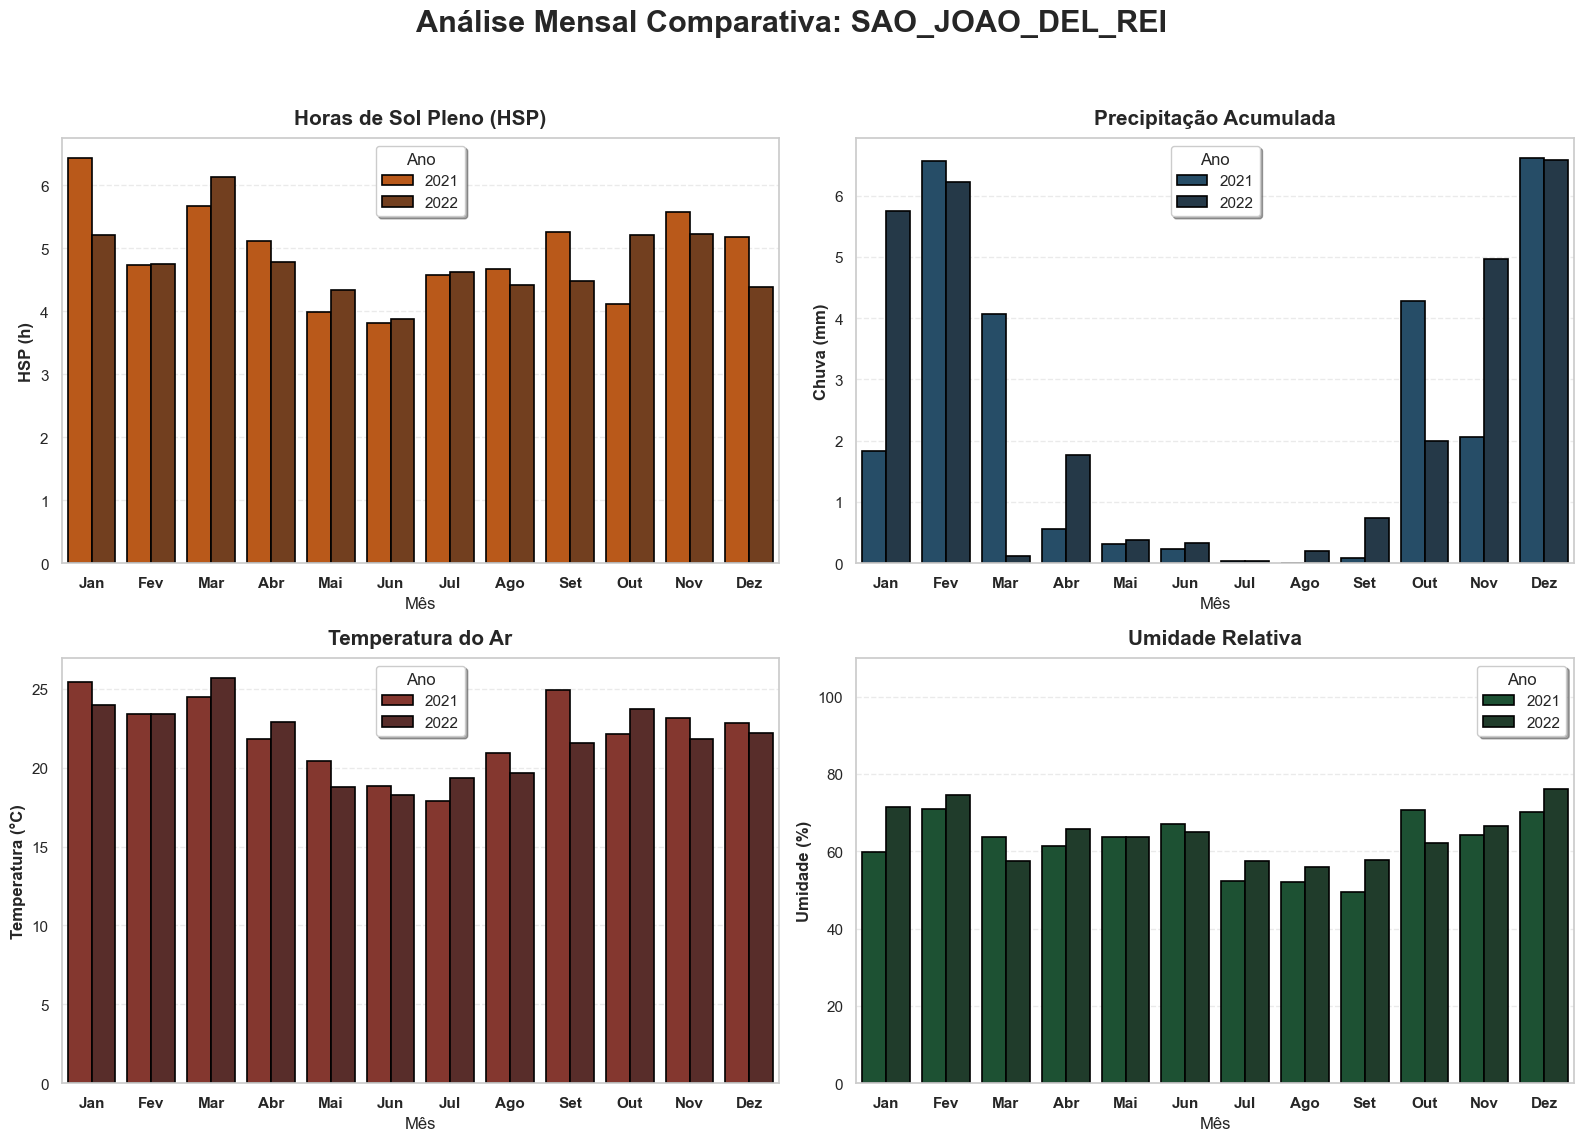

In [106]:
# 1. CARREGAMENTO DOS DADOS
# Lê o arquivo que contém as médias mensais calculadas no script anterior.
arquivo_entrada = "Estatísticas-Estações.csv"
df = pd.read_csv(arquivo_entrada, sep=';', decimal=',')

# --- TRATAMENTO DE TIPOS ---
# Como os dados estão agrupados, não há uma coluna de "Data" completa. 
# Convertemos Ano e Mes para inteiros para garantir que o Seaborn os trate como categorias discretas.
df['Ano'] = df['Ano'].astype(int)
df['Mes'] = df['Mes'].astype(int)

# CONFIGURAÇÃO DE FILTRO: Defina aqui o alvo da sua análise
cidade_escolhida = "SAO_JOAO_DEL_REI"
anos_escolhidos = [2021, 2022] 

# 2. FILTRAGEM DOS DADOS
# Filtra o DataFrame original para conter apenas a cidade e os anos configurados.
# O uso de .isin() permite passar uma lista de anos de uma só vez.
df_plot = df[(df['Cidade'] == cidade_escolhida) & (df['Ano'].isin(anos_escolhidos))].copy()

# Verificação de segurança para evitar erros de plotagem caso os dados não existam.
if df_plot.empty:
    print(f"Erro: Nenhum dado encontrado para {cidade_escolhida} em {anos_escolhidos}")
else:
    # Rótulos amigáveis para substituir os números 1-12 no eixo X.
    meses_nomes = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

    # Define o estilo visual (grade branca de fundo) para melhor legibilidade.
    sns.set_theme(style="whitegrid")

    # 3. CRIAÇÃO DA MOLDURA (CANVAS)
    # plt.subplots(2, 2) cria um painel com 4 gráficos (2 linhas e 2 colunas).
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Título principal do painel consolidado.
    fig.suptitle(f'Análise Mensal Comparativa: {cidade_escolhida}', fontsize=22, y=0.98, fontweight='bold')

    # --- FUNÇÃO AUXILIAR PARA PADRONIZAÇÃO DOS GRÁFICOS ---
    # Esta função evita a repetição de código para os 4 indicadores.
    def plot_custom_bar(ax, y_col, title, label_y, base_color):
        n_anos = len(df_plot['Ano'].unique())
        
        # Cria uma paleta de tons degradê (escuro para claro) baseada na cor base.
        # Isso ajuda a diferenciar visualmente os anos dentro do mesmo gráfico.
        paleta_escura = sns.dark_palette(base_color, n_colors=n_anos + 1, reverse=True)[:n_anos]

        # Gera o gráfico de barras. O parâmetro 'hue' agrupa as barras por ano lado a lado.
        sns.barplot(
            x='Mes', 
            y=y_col, 
            hue='Ano', 
            data=df_plot, 
            ax=ax, 
            palette=paleta_escura, 
            edgecolor="black", # Contorno preto para destacar as barras
            linewidth=1.2
        )
        
        # Ajustes de eixos e rótulos
        ax.set_xticks(range(12)) # Garante que existam 12 posições no eixo X
        ax.set_xticklabels(meses_nomes, fontweight='bold')
        ax.set_title(title, fontsize=15, fontweight='bold', pad=10)
        ax.set_ylabel(label_y, fontsize=12, fontweight='bold')
        ax.set_xlabel('Mês', fontsize=12)
        
        # Legenda e Grade
        ax.legend(title='Ano', frameon=True, shadow=True, loc='best')
        ax.grid(True, axis='y', linestyle='--', alpha=0.4)

    # 4. EXECUÇÃO DA PLOTAGEM
    # Chama a função para cada variável climática usando as colunas médias (_mean).
    
    # Quadrante superior esquerdo: Insolação
    plot_custom_bar(axes[0, 0], 'HSP_mean', 'Horas de Sol Pleno (HSP)', 'HSP (h)', '#D35400')
    
    # Quadrante superior direito: Pluviometria
    plot_custom_bar(axes[0, 1], 'Chuva_mean', 'Precipitação Acumulada', 'Chuva (mm)', '#1B4F72')
    
    # Quadrante inferior esquerdo: Termometria
    plot_custom_bar(axes[1, 0], 'Temp_mean', 'Temperatura do Ar', 'Temperatura (°C)', '#922B21')
    
    # Quadrante inferior direito: Higrometria
    plot_custom_bar(axes[1, 1], 'Umi_mean', 'Umidade Relativa', 'Umidade (%)', '#145A32')
    
    # Ajuste manual do limite da umidade para manter a proporção de 0 a 100%.
    axes[1, 1].set_ylim(0, 110)

    # Ajusta o espaçamento entre os subplots para evitar sobreposição de textos.
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Exibe o resultado final.
    plt.show()

#### 5.1.2 Análise Interanual (São João del-Rei, 2021-2022)
<span style="color:Blue">
Para validar a metodologia de visualização interanual, os gráficos de barras foram aplicados ao histórico da estação de **São João del-Rei (MG)**, contrastando os dois anos (2021-2022). O diagnóstico considera a forte sazonalidade climática característica do local, dividida entre períodos úmidos (primavera/verão) e secos (outono/inverno).

A correlação entre os quatro painéis gerados revela os seguintes padrões fundamentais:

**1. Horas de Sol Pleno (HSP - Recurso Fotovoltaico)**
* **Sazonalidade do Inverno:** Os meses de maio e junho representaram o "vale" de geração (menor captação), mantendo-se altamente previsíveis e similares em ambos os anos.
* **Anomalias de Captação:** Observou-se uma queda expressiva no índice de HSP em janeiro de 2022 (comparado a 2021), fortemente associada a um período de alta nebulosidade. 
* **Deslocamento de Picos:** Na primavera de 2021, o mês de setembro apresentou condições excelentes para radiação. Já em 2022, ocorreu um deslocamento climático, com o pico de radiação primaveril concentrando-se no mês de outubro.

**2. Precipitação Acumulada (Regime Pluviométrico)**
* **Perfil Tropical:** Fevereiro e dezembro consolidaram-se como os meses de pico pluviométrico nos dois ciclos, ratificando o regime tropical de chuvas de verão.
* **Variações Severas de Transição:** Ocorreram inversões bruscas em meses específicos. Março de 2021 acumulou precipitações significativas (cerca de 4 mm/dia de média), ao passo que março de 2022 foi um mês de seca extrema. Em contrapartida, janeiro e novembro de 2022 registraram aumentos expressivos de volume em relação a 2021 (explicando as perdas de HSP nos mesmos períodos).

**3. Temperatura do Ar (Estresse Térmico dos Módulos)**
* **Estabilidade Geral:** Na maior parte do ano, a variação térmica interanual mostrou-se estável, o que facilita o cálculo de perdas térmicas médias em simulações fotovoltaicas.
* **Inverno e Calor Atípicos:** O trimestre de inverno de 2021 (maio, junho e julho) registrou médias inferiores às de 2022, indicando um período mais frio. Curiosamente, a transição para a primavera em setembro de 2021 despontou com temperaturas visivelmente mais quentes que as do ano subsequente.

**4. Umidade Relativa do Ar**
* **Correlação Pluviométrica Direta:** O comportamento da umidade refletiu espelhadamente o gráfico de chuvas. Janeiro de 2022 foi mais úmido que o de 2021, enquanto outubro sofreu o efeito inverso.
* **Aridez de Setembro:** Setembro consolidou-se como o mês de maior aridez nos dois ciclos, sendo a atmosfera de 2021 marginalmente mais seca.
* **Fechamento de Ano:** Dezembro de 2022 apresentou umidade relativa superior a 2021, sugerindo um final de ano com densa cobertura de nuvens e maior impacto de atenuação na geração solar.

### 5.2 Análise Estatísticas Diários 
<span style="color:Blue">
Para viabilizar as modelagens preditivas e as análises focadas no comportamento diário das variáveis climáticas, foi desenvolvida uma rotina de engenharia de dados estruturada no fluxo **ETL (Extração, Transformação e Carga)**. Este processo arquitetural converte o acervo de dados brutos em um *dataset* analítico otimizado.

A implementação técnica desta etapa foi fundamentada em quatro pilares de processamento computacional:

1. **ETL (Extração, Transformação e Carga):**
   * **Extração:** O algoritmo percorre iterativamente os diretórios validados das estações, identificando e instanciando os arquivos CSV referentes aos 5 anos de histórico.
   * **Transformação:** Aplica-se a limpeza de caracteres textuais inconsistentes, a conversão de tipagem de dados e a mudança da escala cronológica (de horária para diária).
   * **Carga:** Os dados processados de todas as localidades são exportados e consolidados em um único artefato tabular (`Dados-Diarios-Estacoes.csv`).

2. **Indexação Cronológica e Processamento de Séries Temporais:**
   Para habilitar as funções nativas de séries temporais da biblioteca Pandas, o formato cronológico bruto exigiu adequação.
   * Removendo sufixos textuais de fuso horário (como " UTC") e caracteres de formatação (":"), transformou-se uma *string* complexa em um formato legível pela máquina.
   * A coluna de tempo foi convertida e configurada como o **índice** (Index) do `DataFrame` no formato `datetime`. Esta ação é o pré-requisito matemático para viabilizar as operações de agrupamento que se seguem.

3. **Redução de Dimensionalidade (Resampling) e Regras de Agregação:**
   Os dados originais do INMET possuem granularidade horária (24 medições diárias). Aplicou-se o método matricial `.resample('D')` para comprimir as 13 instâncias em um único registro diário representativo, utilizando lógicas estatísticas distintas para cada grandeza térmica ou energética:
   * **Soma Acumulada (`sum`):** Aplicada à Precipitação e à Radiação Global para obtenção da incidência e volume totais diários.
   * **Tendência Central (`mean`):** Aplicada à Temperatura e Umidade Relativa para determinar o perfil médio do dia.
   * **Métrica de Viabilidade (HSP):** Implementou-se o cálculo analítico de Horas de Sol Pleno (HSP). A radiação diária acumulada (em kJ/m²) foi matematicamente convertida pela constante de 3600, resultando no tempo equivalente de geração solar plena, parâmetro fundamental na engenharia fotovoltaica.

4. **Padronização e Rastreabilidade de Saída:**
   O script também incorpora rotinas de usabilidade para garantir a integridade de aplicações futuras de *Machine Learning*:
   * **Dicionário e Simplificação:** A renomeação estrutural de colunas (ex: substituindo `Radiacao_Kj_m2` por terminologias concisas) previne falhas de sintaxe em códigos sequenciais.
   * **Metadados Espaciais:** As informações de origem (Estado e Cidade) foram injetadas em todas as linhas, garantindo rastreabilidade espacial ininterrupta na eventual mesclagem com dados de outras regiões.
   * **Otimização Numérica:** A aplicação do método `.round(2)` limitou a precisão dos cálculos de média a duas casas decimais, reduzindo a alocação de memória do arquivo final sem comprometer o rigor científico da análise.

In [107]:
# Ignora avisos de inferência de formato de data para manter o console limpo.
# Isso evita mensagens repetitivas quando o Pandas encontra formatos como '2021-01-01' ou '01/01/2021'.
warnings.filterwarnings("ignore", message="Could not infer format")

# 1. CONFIGURAÇÃO DE CAMINHOS
# Define o diretório onde estão as pastas de cada estação (ex: MG-SAO_JOAO-...).
diretorio_raiz = Path(r"C:\Users\yuric\OneDrive\Documentos\Projeto Machine Learning\Dados\Arquivos 5 anos Filtrados")

# Nome do arquivo consolidado final que será usado para gerar os gráficos de Boxplot.
arquivo_saida = Path("Dados-Diarios-Estacoes.csv")


# 2. PROCESSAMENTO MULTI-ESTAÇÕES (NÍVEL DIÁRIO)
# Lista que armazenará os blocos de dados processados de cada estação antes da união final.
lista_consolidada = []

# Varre o diretório raiz para identificar cada pasta de estação.
for pasta in diretorio_raiz.iterdir():
    # Garante que estamos processando apenas pastas (ignora arquivos soltos na raiz).
    if not pasta.is_dir():
        continue
    
    # Extração de Metadados: Quebra o nome da pasta para identificar o estado e a cidade.
    # Ex: "MG-SAO_JOAO" -> uf = "MG", cidade = "SAO_JOAO"
    partes_nome = pasta.name.split('-')
    uf = partes_nome[0]
    cidade = partes_nome[1]

    # Localiza todos os arquivos .csv (cada um representando um ano) dentro da pasta da estação.
    arquivos_csv = list(pasta.glob("*.csv"))
    if not arquivos_csv:
        continue

    # Lê todos os CSVs da estação e os "empilha" em um único DataFrame inicial.
    # Usa ';' como separador e ',' como decimal, seguindo o padrão das tabelas do INMET.
    df_estacao = pd.concat([pd.read_csv(f, sep=';', decimal=',') for f in arquivos_csv], ignore_index=True)

    # --- TRATAMENTO DE TEMPO ---
    # Limpa a coluna 'Hora': remove o texto ' UTC' e os ':' para que vire um número/texto limpo.
    df_estacao['Hora'] = df_estacao['Hora'].astype(str).str.replace(' UTC', '').str.replace(':', '')
    
    # Cria uma coluna 'Data_Hora' combinando data e hora, convertendo para o formato Datetime do Python.
    # errors='coerce' garante que datas inválidas virem 'NaT' (nulo) em vez de travar o código.
    df_estacao['Data_Hora'] = pd.to_datetime(df_estacao['Data'] + ' ' + df_estacao['Hora'], errors='coerce')
    
    # Transforma 'Data_Hora' no Índice do DataFrame. Isso é OBRIGATÓRIO para usar o método .resample().
    df_estacao.set_index('Data_Hora', inplace=True)
    
    # Remove qualquer linha que tenha falhado na conversão da data (índice nulo).
    df_estacao = df_estacao[df_estacao.index.notnull()]
    
    if df_estacao.empty:
        continue
    
    # --- CONVERSÃO PARA NUMÉRICO ---
    # Dicionário para renomear colunas técnicas para nomes curtos e amigáveis.
    colunas_alvo = {
        'Radiacao_Kj_m2': 'Rad',
        'Umidade_Rel_%': 'Umi',
        'Temp_Ar_C': 'Temp',
        'Precipitacao_mm': 'Chuva'
    }
    # Garante que os valores meteorológicos sejam tratados como números (float) e não como texto.
    for col_orig, col_curta in colunas_alvo.items():
        df_estacao[col_curta] = pd.to_numeric(df_estacao[col_orig], errors='coerce')

    # --- AGREGAÇÃO DIÁRIA (RESAMPLE) ---
    # Aqui o código reduz 24 linhas (horas) para 1 linha (dia).
    res_diario = pd.DataFrame()
    
    # Cálculo de HSP (Horas de Sol Pleno): Soma a radiação do dia e divide por 3600 seg.
    res_diario['HSP'] = df_estacao['Rad'].resample('D').sum() / 3600
    
    # Agregações estatísticas: Média para Temperatura/Umidade e Soma para Chuva.
    res_diario['Temp_Media'] = df_estacao['Temp'].resample('D').mean()
    res_diario['Umi_Media'] = df_estacao['Umi'].resample('D').mean()
    res_diario['Chuva_Acumulada'] = df_estacao['Chuva'].resample('D').sum()

    # --- ORGANIZAÇÃO FINAL ---
    # Move a data do índice de volta para uma coluna comum para facilitar a exportação.
    res_diario = res_diario.reset_index()
    res_diario.rename(columns={'Data_Hora': 'Data'}, inplace=True)
    
    # Cria colunas de Ano e Mês separadas, facilitando filtros rápidos no futuro.
    res_diario['Ano'] = res_diario['Data'].dt.year
    res_diario['Mes'] = res_diario['Data'].dt.month

    # Insere as informações de UF e Cidade nas primeiras posições da tabela.
    res_diario.insert(0, 'UF', uf)
    res_diario.insert(1, 'Cidade', cidade)
    
    # Arredonda tudo para 2 casas decimais e adiciona à lista consolidada.
    lista_consolidada.append(res_diario.round(2))

# 3. EXPORTAÇÃO
if lista_consolidada:
    # Une os dados de todas as estações processadas em uma única tabela mestre.
    df_final = pd.concat(lista_consolidada, ignore_index=True)
    
    # Salva o arquivo CSV final pronto para ser lido pelo script de visualização.
    df_final.to_csv(arquivo_saida, sep=';', index=False, decimal=',')
    print(f"\nSucesso! O arquivo '{arquivo_saida}' está pronto.")
else:
    print("Erro: Nenhum dado foi processado.")


Sucesso! O arquivo 'Dados-Diarios-Estacoes.csv' está pronto.


### 5.2.1 Diagnóstico de Variabilidade Intra-mensal (Boxplots)
<span style="color:Blue">
Para aprofundar a análise climática, implementou-se o uso de **Diagramas de Caixa (Boxplots)**. Enquanto as médias mensais indicam a tendência geral, o Boxplot permite visualizar a distribuição dos dados diários dentro de cada mês, evidenciando a estabilidade ou a volatilidade do recurso solar e das condições térmicas.

A implementação técnica desta ferramenta de diagnóstico seguiu os seguintes critérios:

1. **Segmentação e Filtragem Direcionada:**
   O algoritmo permite o isolamento de estações e anos específicos para análise. Esta segmentação é vital para evitar a poluição visual do dashboard, permitindo que o estudo foque nas particularidades climáticas de uma localidade isolada sem a interferência de dados globais da base.

2. **Robustez Estatística da Visualização:**
   A escolha pelo Boxplot justifica-se por sua capacidade de sintetizar quatro dimensões estatísticas em uma única representação visual por mês:
   * **Mediana:** Indica o valor central de geração ou temperatura, minimizando o impacto de valores extremos.
   * **Dispersão Interquartil (Caixa):** Revela a consistência dos dados; uma caixa menor indica que os dias daquele mês foram meteorologicamente similares.
   * **Whiskers (Bigodes):** Delimitam a fronteira da variabilidade esperada.
   * **Outliers (Pontos Atípicos):** Identificam eventos raros, como chuvas torrenciais em períodos secos ou dias de radiação solar excepcionalmente alta, fundamentais para análises de resiliência de sistemas.

3. **Configuração de Dashboard Multi-variável (Layout 2x2):**
   Utilizou-se a estrutura `plt.subplots(2, 2)` para criar uma grade de comparação simultânea entre as quatro variáveis críticas para a engenharia fotovoltaica e meteorologia:
   * **HSP (Laranja):** Avaliação do potencial fotovoltaico e dispersão da radiação.
   * **Precipitação (Azul):** Identificação de meses de seca e severidade de eventos pluviométricos diários.
   * **Temperatura (Vermelho):** Monitoramento da estabilidade térmica operacional da região.
   * **Umidade (Verde):** Parâmetro de saturação do ar, com escala normalizada (0-105%) para garantir a integridade da interpretação visual.

4. **Automação e Padronização via Funções:**
   A criação da função `plot_custom_boxplot` reflete uma abordagem de desenvolvimento modular. Esta estratégia assegura a padronização estética entre todos os gráficos, garante o tratamento automático dos rótulos temporais (meses do ano) e otimiza a manutenção do código, permitindo ajustes globais de estilo em um único ponto de instrução.

Gerando gráficos para o ano 2021...


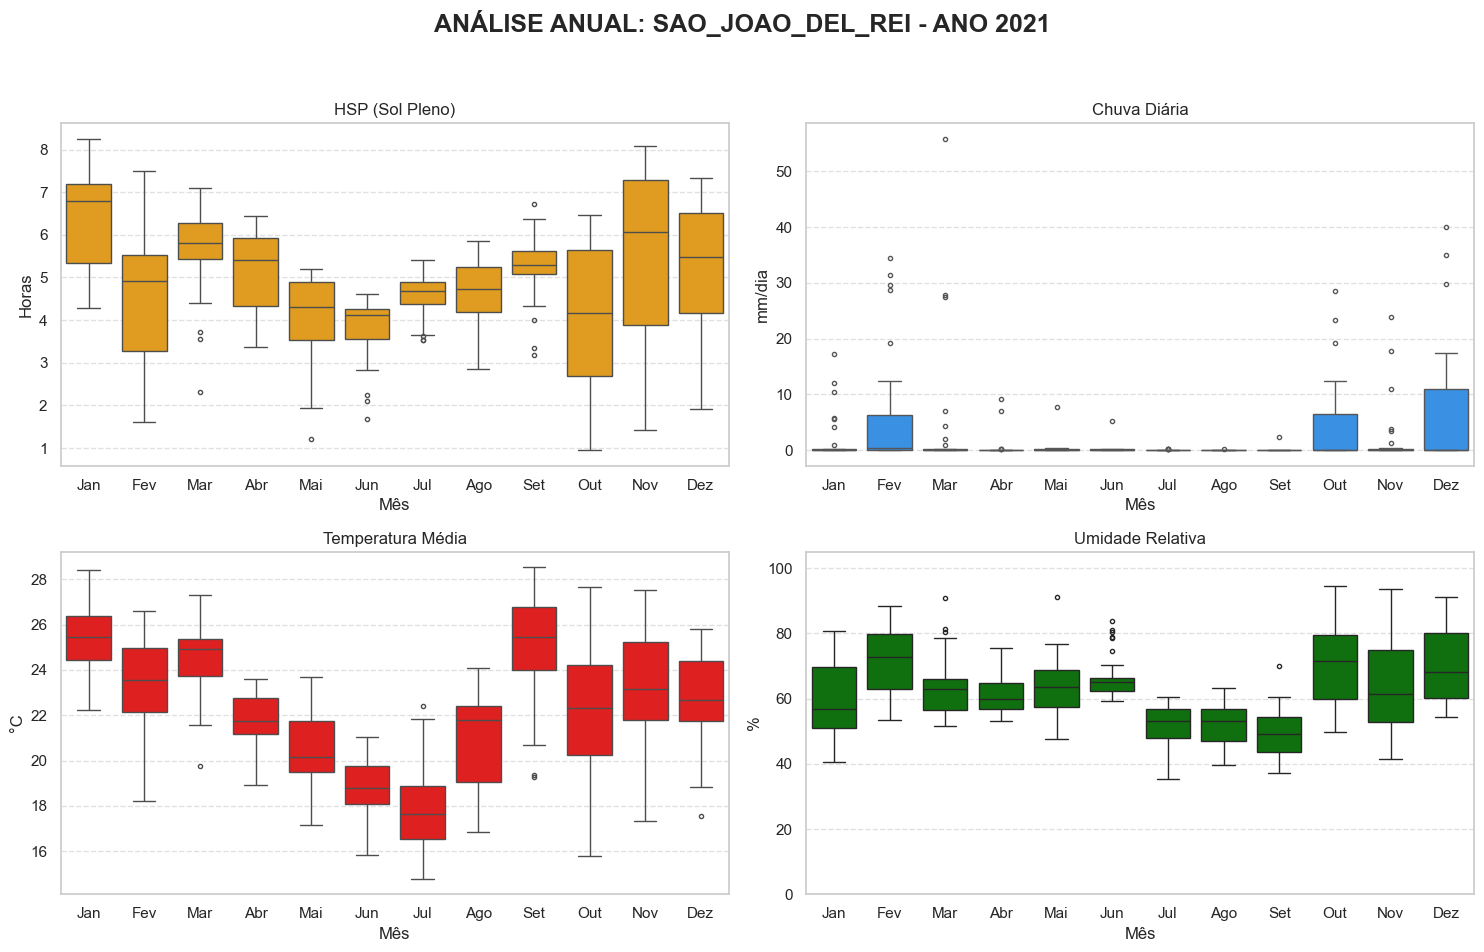

In [108]:
# 1. Carregar os dados consolidados do passo anterior
# O separador ';' e decimal ',' garantem que o Python leia corretamente o padrão brasileiro/INMET.
df = pd.read_csv("Dados-Diarios-Estacoes.csv", sep=';', decimal=',')

# Converte a coluna 'Data' de texto para o formato datetime do Pandas (essencial para extrair datas).
df['Data'] = pd.to_datetime(df['Data'])


# CONFIGURAÇÃO: ESCOLHA A ESTAÇÃO E OS ANOS
# Define qual cidade será analisada (deve ser exatamente igual ao nome da pasta/coluna 'Cidade').
cidade_escolhida = "SAO_JOAO_DEL_REI"  

# Lista de anos que você deseja gerar painéis. O loop passará por cada item desta lista.
anos_para_processar = [2021] 

# Lista para servir de rótulos (labels) no eixo X dos gráficos.
meses_nomes = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

# --- FUNÇÃO AUXILIAR PARA O BOXPLOT ---
# Esta função automatiza a criação de gráficos repetitivos, mantendo o padrão visual.
def plot_custom_boxplot(ax, df_ano, y_col, title, label_y, color):
    # sns.boxplot: Desenha o gráfico de bigodes (mostra mediana, quartis e outliers).
    # fliersize=3 controla o tamanho dos pontos que representam valores fora da curva (outliers).
    sns.boxplot(x='Mes', y=y_col, data=df_ano, ax=ax, color=color, fliersize=3)
    
    # Configurações de escala e rótulos do eixo X (Mês 1 ao 12).
    ax.set_xticks(range(12)) 
    ax.set_xticklabels(meses_nomes)
    
    # Estética do gráfico: títulos, nomes dos eixos e grade de fundo.
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(label_y)
    ax.set_xlabel('Mês')
    ax.grid(True, axis='y', linestyle='--', alpha=0.6) # Grade horizontal tracejada

# --- 2. LOOP PARA GERAR UM PAINEL POR ANO ---
for ano in anos_para_processar:
    # Filtra o DataFrame principal para pegar apenas a cidade e o ano atuais do loop.
    # O .copy() evita avisos de "SettingWithCopyWarning" ao manipular os dados filtrados.
    df_ano = df[(df['Cidade'] == cidade_escolhida) & (df['Ano'] == ano)].copy()
    
    # Se não houver dados para os filtros selecionados, avisa o usuário e pula para o próximo ano.
    if df_ano.empty:
        print(f"Aviso: Nenhum dado encontrado para {cidade_escolhida} no ano {ano}. Pulando...")
        continue

    print(f"Gerando gráficos para o ano {ano}...")

    # Cria a "moldura" da figura com 4 espaços (2 linhas e 2 colunas).
    # figsize=(15, 10) define o tamanho da imagem final em polegadas.
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Adiciona um título principal centralizado no topo do painel.
    fig.suptitle(f'ANÁLISE ANUAL: {cidade_escolhida} - ANO {ano}', fontsize=18, fontweight='bold', y=0.98)

    # --- PREENCHIMENTO DOS SUBPLOTS ---
    # Cada linha abaixo chama a função customizada para preencher um quadrante do painel.
    
    # [0, 0] -> Canto superior esquerdo: Radiação Solar (HSP)
    plot_custom_boxplot(axes[0, 0], df_ano, 'HSP', 'HSP (Sol Pleno)', 'Horas', 'orange')
    
    # [0, 1] -> Canto superior direito: Chuva
    plot_custom_boxplot(axes[0, 1], df_ano, 'Chuva_Acumulada', 'Chuva Diária', 'mm/dia', 'dodgerblue')
    
    # [1, 0] -> Canto inferior esquerdo: Temperatura
    plot_custom_boxplot(axes[1, 0], df_ano, 'Temp_Media', 'Temperatura Média', '°C', 'red')
    
    # [1, 1] -> Canto inferior direito: Umidade
    plot_custom_boxplot(axes[1, 1], df_ano, 'Umi_Media', 'Umidade Relativa', '%', 'green')
    
    # Ajuste manual para a Umidade: fixa o eixo Y entre 0 e 105% (evita escalas estranhas).
    axes[1, 1].set_ylim(0, 105)

    # Ajusta automaticamente o espaçamento entre os subplots para não sobrepor títulos e eixos.
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Exibe o painel completo na tela.
    plt.show()

### 5.2.2 Interpretação Diagnóstica da Variabilidade Diária (Ano Base: 2021)
<span style="color:Blue">
A aplicação da ferramenta de Boxplots à série temporal permitiu decupar o comportamento intramesal das grandezas climáticas. O diagnóstico leva em consideração a ciclicidade sazonal da região, mapeada tradicionalmente entre o verão chuvoso e o inverno predominantemente seco. 

A análise das estatísticas de dispersão (medianas, quartis e *outliers*) revelou os seguintes comportamentos macroclimáticos:

**1. Recurso Fotovoltaico e Intermitência (HSP)**
* **Vale de Inverno:** Constatou-se uma queda estrutural na incidência solar entre maio e agosto. O mês de junho destacou-se pela menor variabilidade temporal (intervalo interquartil severamente comprimido), com a geração concentrada de forma estável e previsível em torno de 4 HSP/dia.
* **Alta Intermitência:** Os meses de fevereiro, outubro e novembro exibiram elevada amplitude interquartil (representada por caixas visualmente alongadas). Esta característica estatística aponta para uma forte intermitência de radiação, traduzindo-se na alternância abrupta entre dias de céu limpo (alta geração) e dias de densa nebulosidade (baixa geração).
* **Picos de Geração:** Janeiro e novembro registraram os maiores *outliers* superiores, com dias específicos ultrapassando o limiar de 8 HSP.

**2. Regime Pluviométrico e Eventos Extremos**
* **Estiagem Rigorosa:** No período compreendido entre abril e setembro, a variação pluviométrica diária foi estatisticamente irrelevante (ausência de amplitude das caixas), caracterizando uma estação seca rigorosa. O volume anual concentrou-se majoritariamente nos meses de verão e primavera (jan, fev, out, dez).
* **Anomalias Climáticas (*Outliers*):** A visualização de pontos atípicos forneceu *insights* sobre precipitações extremas. Em março, apesar da média pluviométrica baixa, o Boxplot capturou um evento torrencial isolado superior a 50 mm/dia. Dezembro apresentou caixas mais largas, indicando chuvas distribuídas de intensidade moderada a forte.

**3. Perfil Térmico e Amplitude Sazonal**
* **Inverno e Estabilidade no Verão:** Houve um declínio térmico acentuado a partir de abril, culminando no vale térmico de julho (mediana inferior a 18°C e mínimas de 14°C). Em contrapartida, o primeiro trimestre (janeiro a março) apresentou "caixas" pequenas com altas medianas, refletindo estabilidade em temperaturas quentes constantes.
* **Volatilidade de Transição:** O mês de setembro destoou dos demais pela enorme amplitude interquartil. Como um mês de transição primaveril, a estação registrou desde dias de temperatura amena até picos absolutos de calor superiores a 27°C, submetendo os módulos fotovoltaicos à maior amplitude térmica do ano.

**4. Saturação Atmosférica (Umidade Relativa)**
* **Correlação Pluviométrica:** Fevereiro, outubro e dezembro operaram com as maiores medianas de umidade (acima de 70%), em sintonia direta com o volume de precipitação.
* **Aridez e Ruptura Sazonal:** O trimestre de julho a setembro marcou o ápice da aridez. Setembro foi estatisticamente o mais severo, com a mediana recuando a 50% e registros mínimos na faixa de 40%, indicando atmosfera altamente seca. Em outubro, o gráfico demonstra um "salto" estatístico abrupto para cima na caixa interquartil, evidenciando o fim efetivo do período seco do ciclo de 2021.

### 5.3 Análise das curvas horárias
<span style="color:green">
Nessa etapa, o objetivo foi estudar e analisar o comportamento diário das grandezas apresentadas anteriormente, para entender quais locais e épocas do ano oferecem maior segurança na disponibilidade da matriz energética fotovoltaica. Para que fosse possível realizar esse tipo de análise, os dados foram agrupados por hora dentro do mesmo mês, abrangendo o período de 2021 a 2025. Ou seja, cada estação possui seu próprio dicionário, contendo doze meses e, dentro de cada mês, 14 horas, respectivamente das 06:00 às 19:00, com as informações de cada grandeza.


Além disso, para realizar tal análise, foi selecionada uma amostra de maneira pré-determinada, sendo ela a estação do campus Trancredo Neves (CTAN) da nossa universidade. 
Sua identificação nos arquivos é:

* **MG-SAO_JOAO_DEL_REI-A514**

Para essa análise foram elaboradas três etapas:

* **5.3.1** Leitura, separaçãos dos dados em séries temporais horárias e cálculo dos dados estatísticos, salvando em um arquivo `.json`.
* **5.3.2** Leitura do arquivo `.json` gerado e plots e curvas mensais dos dados de Radiação, Precipitação, Umidade e Temperatura.
* **5.3.3** Plots de box plot através utilizando todos os dados para analisar disperção e frêquêcia de cada mês.

#### *5.3.1 Separaçãos dos dados em séries temporais horárias*
<span style="color:green">
**O que foi implementado:**
1. Processamento Estatístico de Estações Meteorológicas e definição do caminho e listagem das pastas de estações

Este script lê dados climáticos de 155 estações meteorológicas ao longo de 5 anos,
calcula estatísticas descritivas por mês e hora do dia, e salva os resultados em um arquivo JSON.
  

In [109]:
# Caminho da pasta principal onde estão todas as pastas das estações
caminho_principal = r"C:\Users\yuric\OneDrive\Documentos\Projeto Machine Learning\Dados\Arquivos 5 anos Filtrados"  # ← ajuste aqui

# Listando todas as pastas de estações automaticamente
pastas_estacoes = [
    pasta for pasta in os.listdir(caminho_principal)
    if os.path.isdir(os.path.join(caminho_principal, pasta)) and pasta.endswith('-Filtrada')
]

<span style="color:green">
2. Definição da função de moda e variáveis globais

Nessa etápa é definida uma função moda para retornar o primeiro valor mais frequente da coluna ignorando valores nulos.
Também é definido as colunas das variáveis de interesse.

In [110]:
# Definindo a função para calcular a moda
def primeira_moda(x):
    moda = x.dropna().mode()
    if moda.empty:
        return float("nan")
    return moda.iloc[0]

colunas = ['Precipitacao_mm', 'Radiacao_Kj_m2', 'Temp_Ar_C', 'Umidade_Rel_%']
anos = range(2021, 2026)

<span style="color:green">
3. Loop principal: leitura e concatenação dos arquivos CSV
- Para cada estação, extrai o código removendo o sufixo `-Filtrada`
- Tenta carregar um arquivo CSV por ano (2021–2025)
- Os CSVs usam `;` como separador e `,` como decimal (padrão brasileiro)
- Concatena todos os anos em um único DataFrame chamado `dados`

4. Pré-processamento: datas, fuso horário e mês
- Converte a coluna `Data` para o tipo `datetime`
- Subtrai 3 horas para ajustar o fuso horário (UTC → Brasília)
- Cria a coluna `Mes` extraindo o número do mês da data

5. Separação dos dados por mês e hora
- Cria um dicionário aninhado `horas[mês][hora]`
- Filtra os dados para cada combinação de mês (1–12) e hora (6h–19h)
- Considera apenas o horário diurno (6h às 19h)

6. Cálculo das estatísticas descritivas

Para cada combinação mês/hora, calcula 7 estatísticas para as 4 variáveis climáticas:

| Estatística    | Descrição                          |
|----------------|------------------------------------|
| Média          | Valor médio                        |
| Mediana        | Valor central                      |
| Moda           | Valor mais frequente               |
| Máximo         | Maior valor registrado             |
| Mínimo         | Menor valor registrado             |
| Desvio Padrão  | Dispersão em relação à média       |
| Variância      | Dispersão ao quadrado              |

- O `.T` transpõe o DataFrame, deixando as estatísticas nas linhas e as variáveis nas colunas

7. Print informando que o processo foi concluído com sucesso

In [111]:
# Dicionário principal: estatisticas_geral[estacao][mes][hora]
estatisticas_geral = {}

for pasta in pastas_estacoes:
    # Extrai o código da estação removendo o sufixo '-Filtrada'
    # Exemplo: 'DF-BRASILIA-A001-Filtrada' → 'DF-BRASILIA-A001'
    estacao = pasta.replace('-Filtrada', '')
    caminho_estacao = os.path.join(caminho_principal, pasta)

    # Carrega os arquivos dos 5 anos da estação
    lista_dfs = []
    for ano in anos:
        arquivo = os.path.join(caminho_estacao, f'{estacao}-{ano}_Filtrada.csv')
        if os.path.exists(arquivo):
            df_ano = pd.read_csv(arquivo, sep=';', decimal=',')
            lista_dfs.append(df_ano)

    # Concatena os anos em um único DataFrame
    dados = pd.concat(lista_dfs, ignore_index=True)

    # Pré-processamento (igual ao código original)
    dados["Data"] = pd.to_datetime(dados["Data"])
    dados["Hora"] = dados["Hora"] - 3
    dados["Mes"] = dados["Data"].dt.month

    # Separando por mês e hora
    horas = {}
    for mes in range(1, 13):
        horas[mes] = {}
        for hora in range(6, 20):
            horas[mes][hora] = dados[dados["Mes"] == mes][dados[dados["Mes"] == mes]['Hora'] == hora]

    # Calculando as estatísticas
    estatisticas = {}
    for mes in range(1, 13):
        estatisticas[mes] = {}
        for hora in range(6, 20):
            df = horas[mes][hora][colunas]
            estatisticas[mes][hora] = pd.DataFrame(
                {
                    'Média':         df.mean(),
                    'Mediana':       df.median(),
                    'Moda':          df.apply(primeira_moda),
                    'Máximo':        df.max(),
                    'Mínimo':        df.min(),
                    'Desvio Padrão': df.std(),
                    'Variância':     df.var()
                },
                index=colunas
            ).T

    # Armazena no dicionário geral
    estatisticas_geral[estacao] = estatisticas

print(f'\nProcessamento concluído! Total de estações processadas: {len(estatisticas_geral)}')



Processamento concluído! Total de estações processadas: 155


<span style="color:green">
8. Conversão e exportação para JSON
   
- Converte todos os DataFrames para dicionários Python (necessário para serializar em JSON)
- Salva o arquivo `estatisticas.json` com:
  - `ensure_ascii=False`: mantém acentos e caracteres especiais
  - `indent=2`: formata o JSON de forma legível

In [112]:
# Convertendo os DataFrames para dicionário antes de salvar
dados_json = {}

for estacao, meses in estatisticas_geral.items():
    dados_json[estacao] = {}
    for mes, horas in meses.items():
        dados_json[estacao][mes] = {}
        for hora, df_stats in horas.items():
            # Converte o DataFrame para dicionário
            dados_json[estacao][mes][hora] = df_stats.to_dict()
            
# Salvando o JSON
caminho_json = os.path.join('estatisticas.json')
with open(caminho_json, 'w', encoding='utf-8') as f:
    json.dump(dados_json, f, ensure_ascii=False, indent=2)

print(f'JSON salvo em: {caminho_json}')

JSON salvo em: estatisticas.json


### *5.3.2 Plots e curvas mensais dos dados de Radiação, Precipitação, Umidade e Temperatura.*
<span style="color:green">
Este script carrega as estatísticas salvas no JSON gerado anteriormente e plota gráficos
das médias horárias de 4 variáveis climáticas para cada mês do ano, salvando uma imagem por mês.


1. Carregamento do arquivo JSON e Reconversão dos dicionários para DataFrames
- Define o caminho do arquivo `estatisticas.json` (na mesma pasta do script)
- Abre e lê o arquivo JSON com codificação UTF-8, carregando os dados na variável `dados_carregados`
- Percorre todas as estações, meses e horas do JSON carregado
- Converte as chaves de mês e hora de `string` para `int` (o JSON salva chaves sempre como texto)
- Reconstrói cada `pd.DataFrame` a partir do dicionário armazenado no JSON
    

In [113]:
# Caminho do arquivo JSON onde estão as estatísticas (no caso na mesma pasta do script))
caminho_json = os.path.join( 'estatisticas.json')

# Abrindo o arquivo JSON para leitura e carregando os dados
with open(caminho_json, 'r', encoding='utf-8') as f:
    dados_carregados = json.load(f)

# Reconvertendo os dicionários de volta para DataFrames
estatisticas_geral = {}
for estacao, meses in dados_carregados.items():
    estatisticas_geral[estacao] = {}
    for mes, horas in meses.items():
        estatisticas_geral[estacao][int(mes)] = {}
        for hora, df_dict in horas.items():
            estatisticas_geral[estacao][int(mes)][int(hora)] = pd.DataFrame(df_dict)

<span style="color:green">
2. Definição da estação e configurações do plot
- Define a estação de interesse: `MG-SAO_JOAO_DEL_REI-A514`
- Define o intervalo de horas a plotar: **6h às 19h** (`range(6, 20)`)
- Cria um dicionário `nomes_meses` para converter número do mês (1–12) em nome por extenso (Janeiro–Dezembro)

In [114]:
estacao = 'MG-SAO_JOAO_DEL_REI-A514'
horas_plot = range(6, 20)

#Convertendo o numero do mês para nome do mês
nomes_meses= {1: 'Janeiro', 2: 'Fevereiro', 3: 'Março', 4: 'Abril', 5: 'Maio', 6: 'Junho',
              7: 'Julho', 8: 'Agosto', 9: 'Setembro', 10: 'Outubro', 11: 'Novembro', 12: 'Dezembro'}

<span style="color:green">
3. Loop mensal: extração das médias horárias
- Para cada mês (1 a 12), extrai a linha `'Média'` de cada hora nos DataFrames reconstruídos
- Monta 4 listas com os valores médios ao longo do dia para cada variável:
  - `radiacao` → `Radiacao_Kj_m2`
  - `precipitacao` → `Precipitacao_mm`
  - `umidade` → `Umidade_Rel_%`
  - `temperatura` → `Temp_Ar_C`

4. Configuração da figura com subplots

- Cria uma figura com **2 linhas × 2 colunas** de gráficos (`figsize=(14, 8)`)
- Define o título geral da figura com o nome do mês e o período (2021–2025)

5. Plotagem dos 4 gráficos

Cada subgráfico exibe a média horária de uma variável, com marcadores de ponto (`marker='o'`) e grade ativada:

| Posição     | Variável           | Cor     |
|-------------|--------------------|---------|
| `axs[0, 0]` | Radiação Solar     | Laranja |
| `axs[0, 1]` | Precipitação       | Azul    |
| `axs[1, 0]` | Umidade Relativa   | Verde   |
| `axs[1, 1]` | Temperatura do Ar  | Vermelho|

- Todos os gráficos têm eixo X com a **hora** e eixo Y com a **unidade da variável**

6. Salvamento da figura e encerramento

- `plt.tight_layout()`: ajusta automaticamente o espaçamento entre os subgráficos
- Salva a figura como `.png` com resolução de **150 DPI**, no formato:
  `grafico_sao_joao_del_rei_01_Janeiro.png`, `..._02_Fevereiro.png`, etc.
- `plt.close()`: **fecha a figura** para liberar memória antes de criar a próxima — essencial em loops longos
- Imprime uma confirmação para cada mês salvo e uma mensagem final ao concluir todos os 12

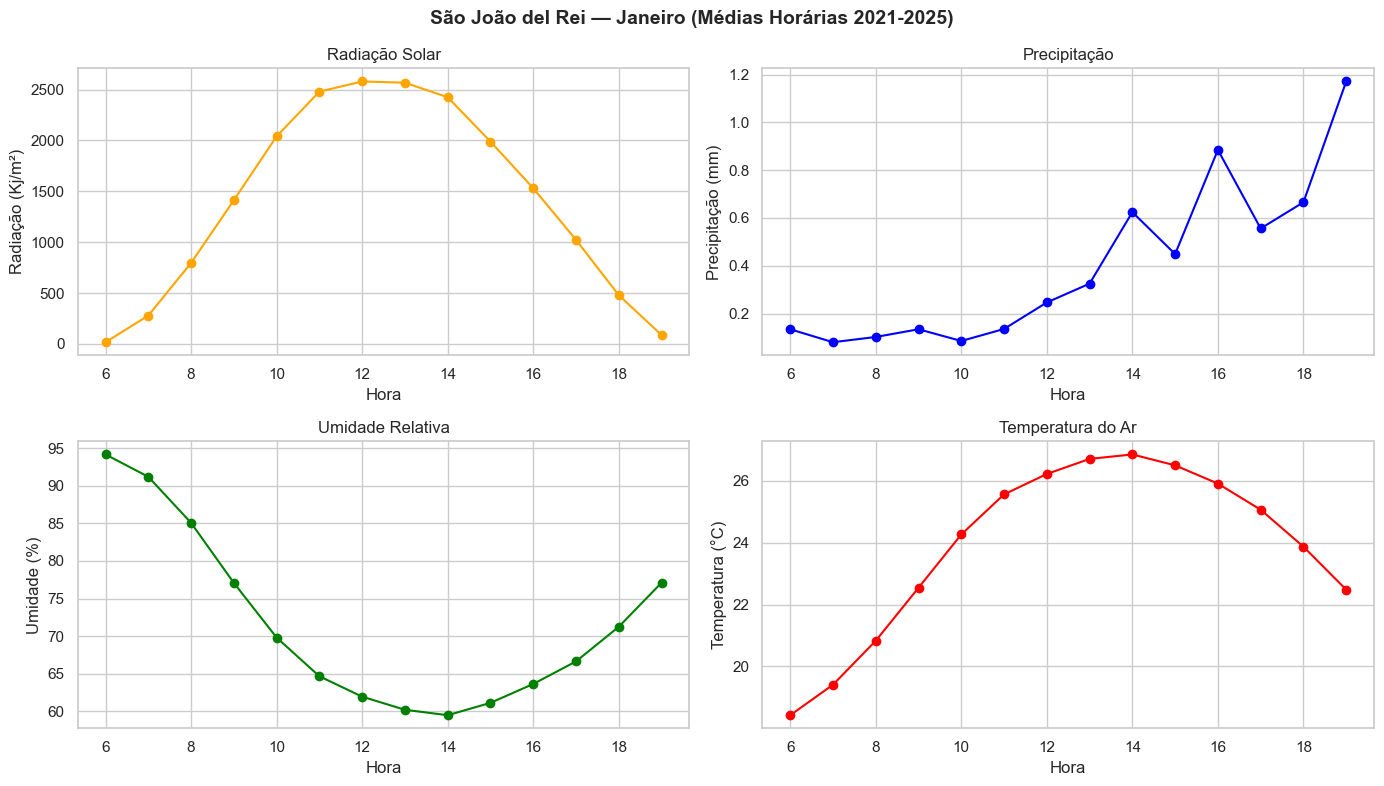

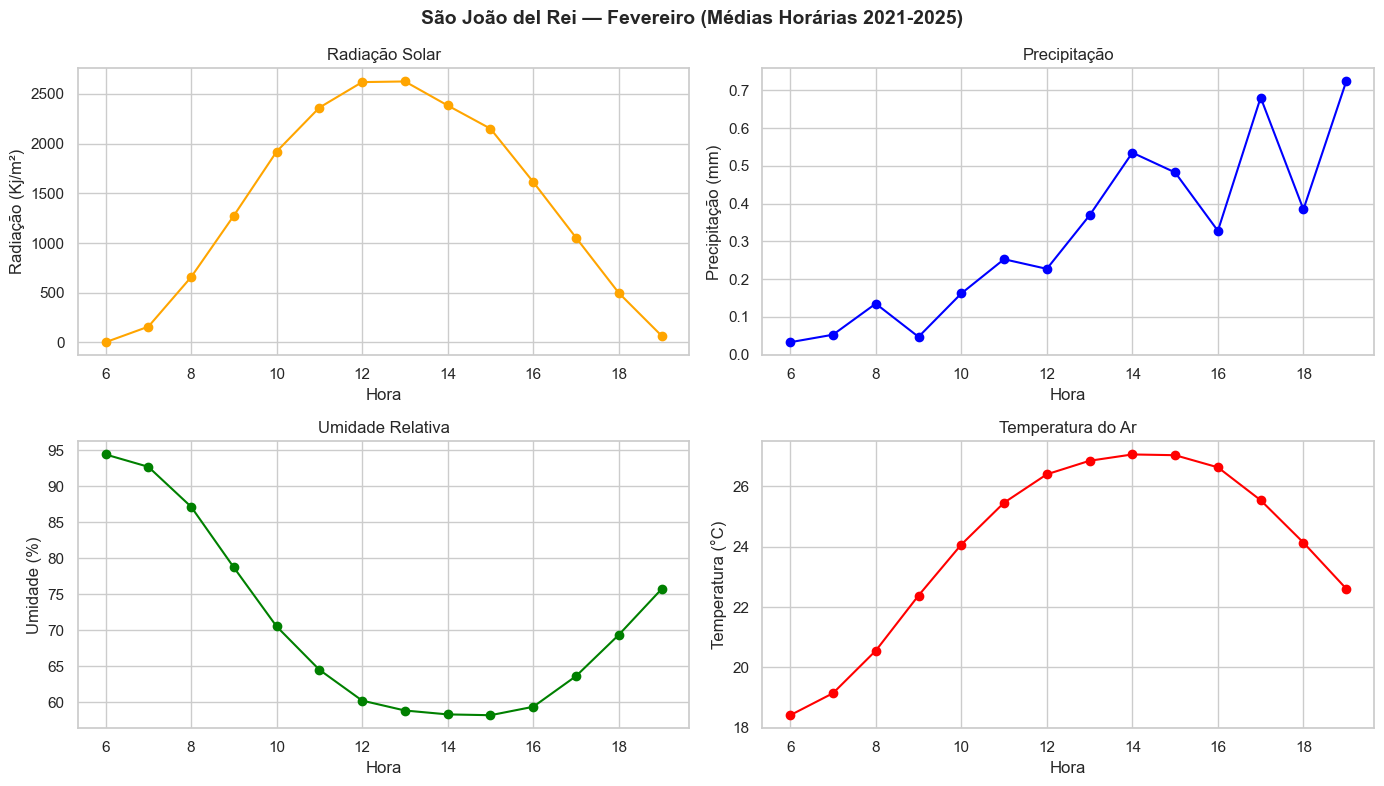

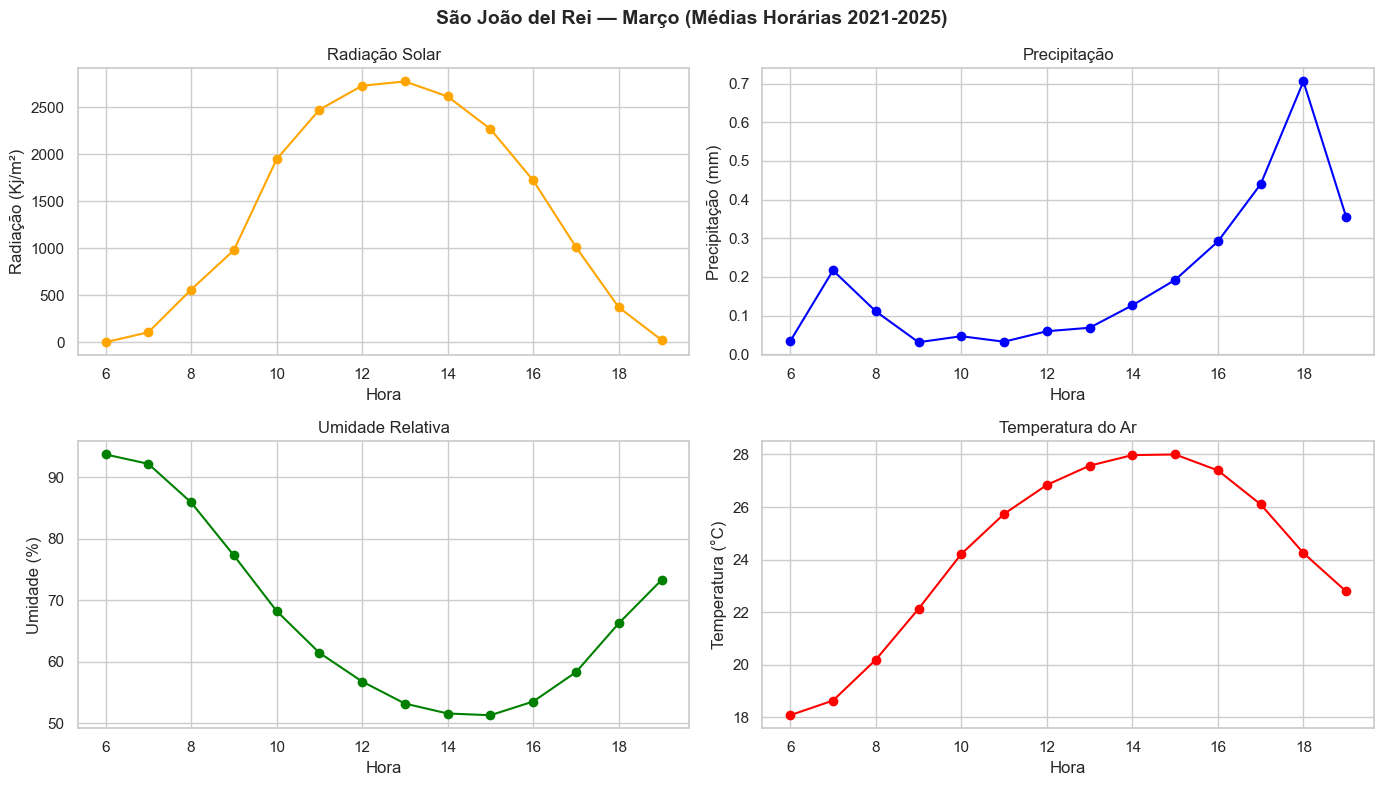

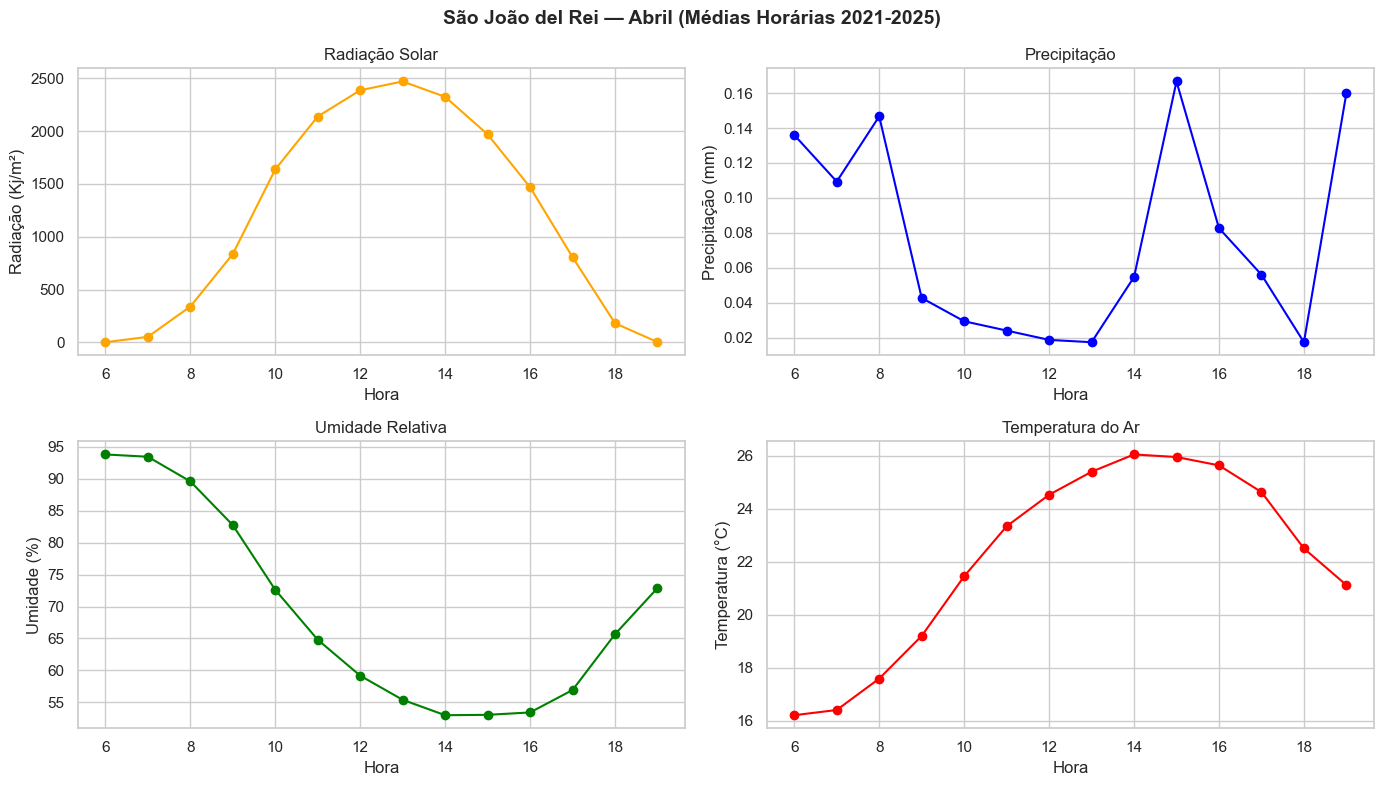

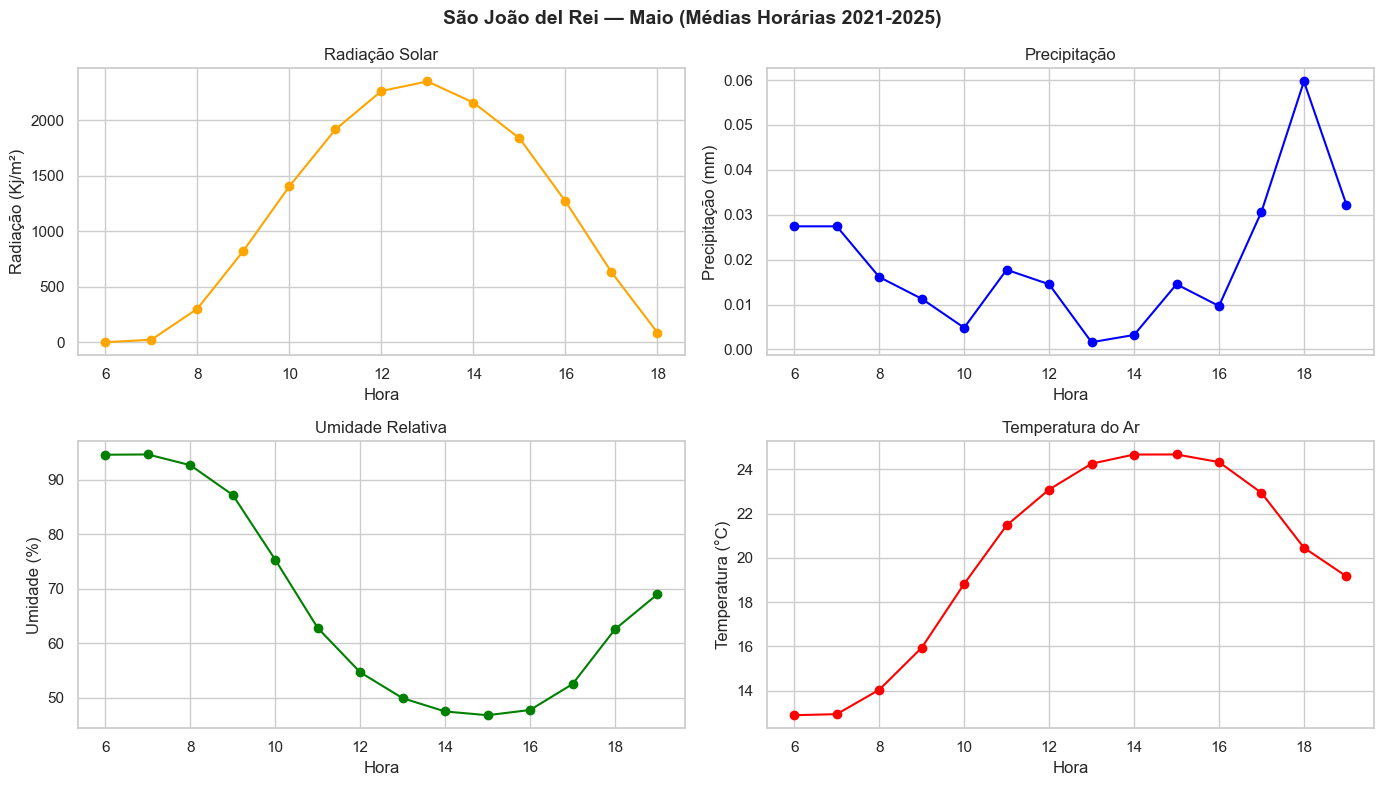

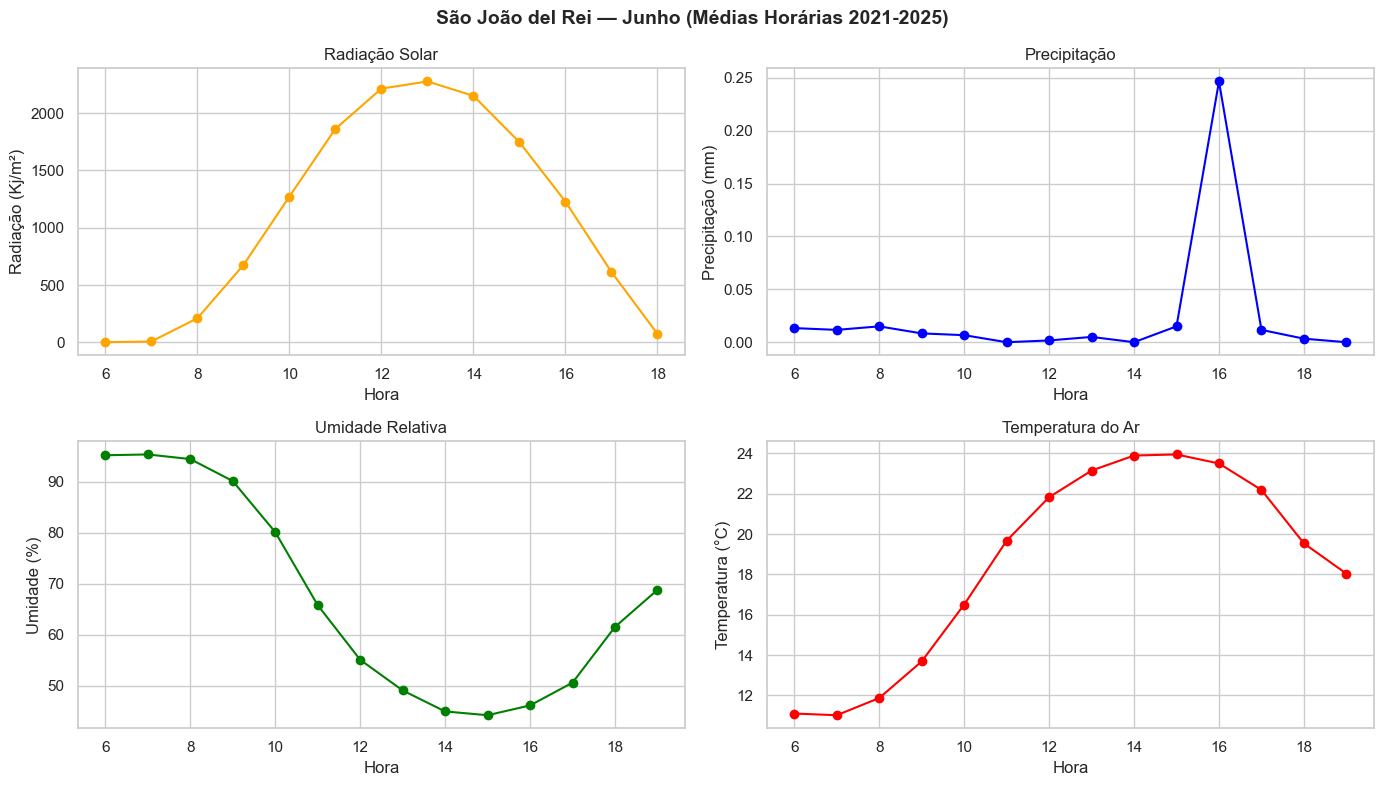

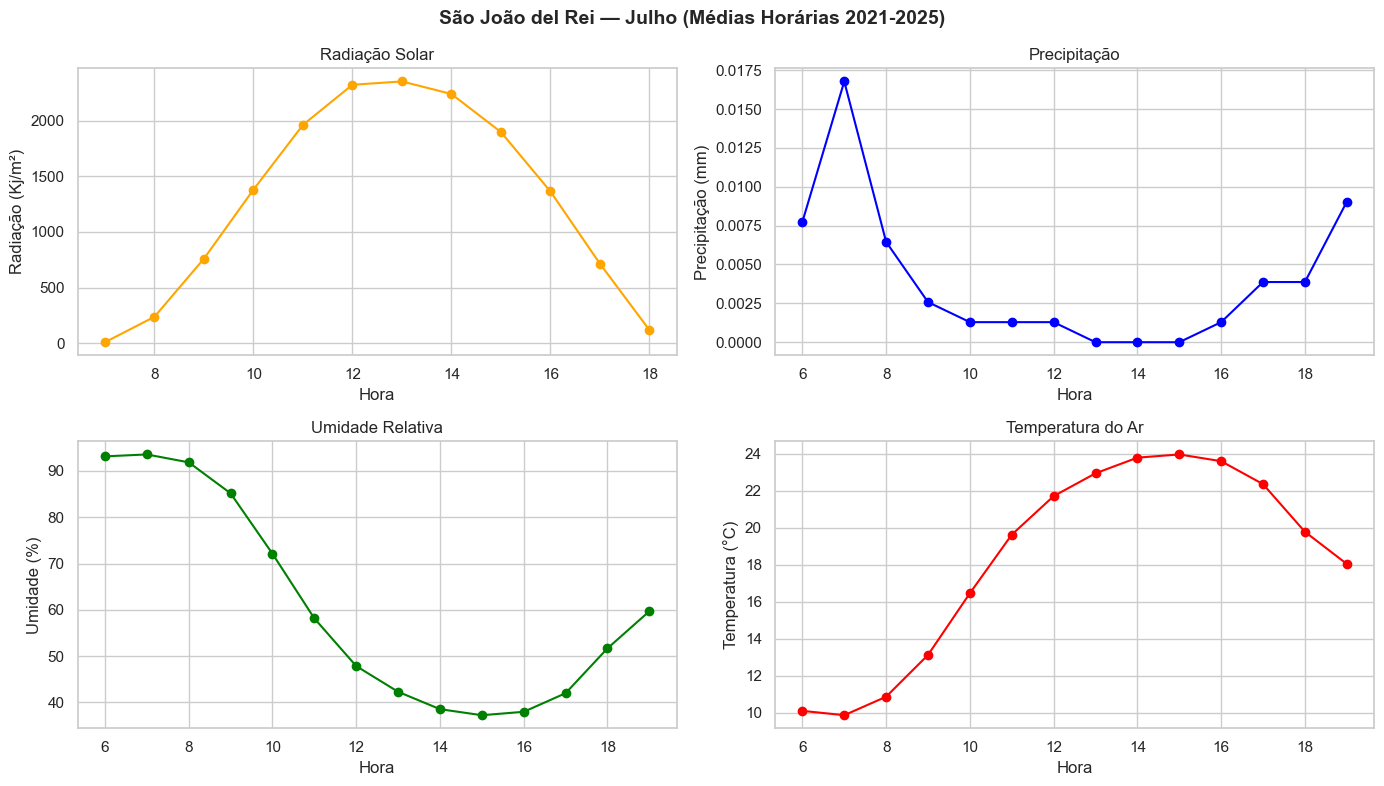

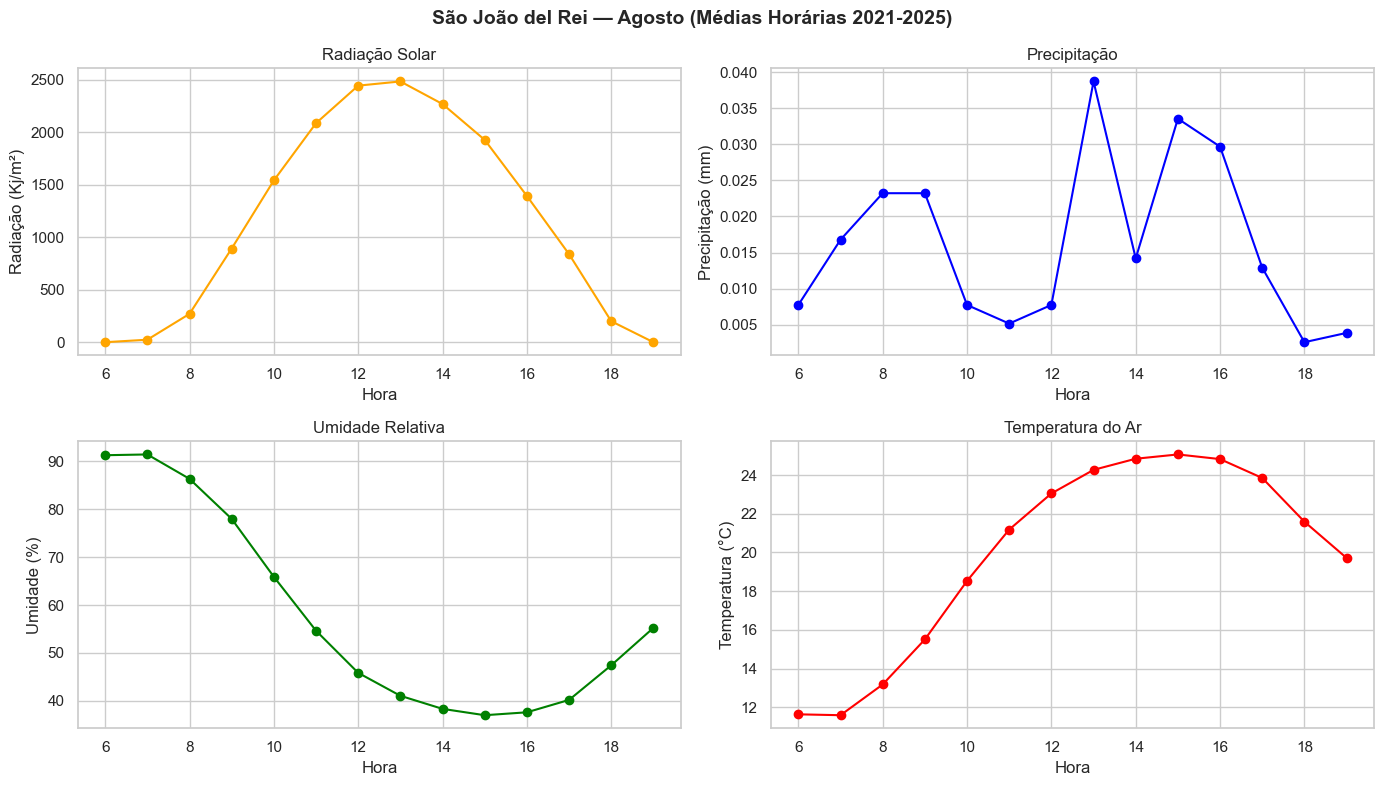

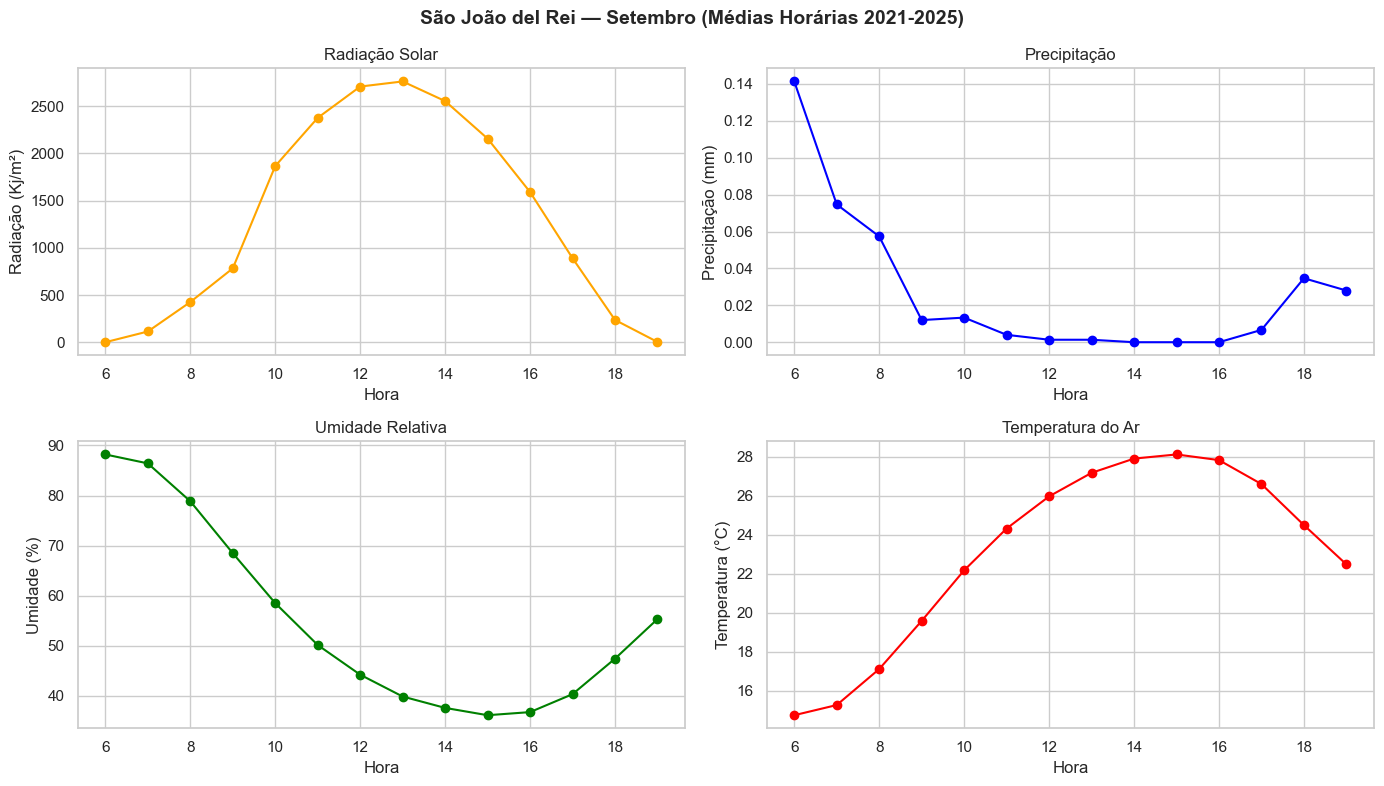

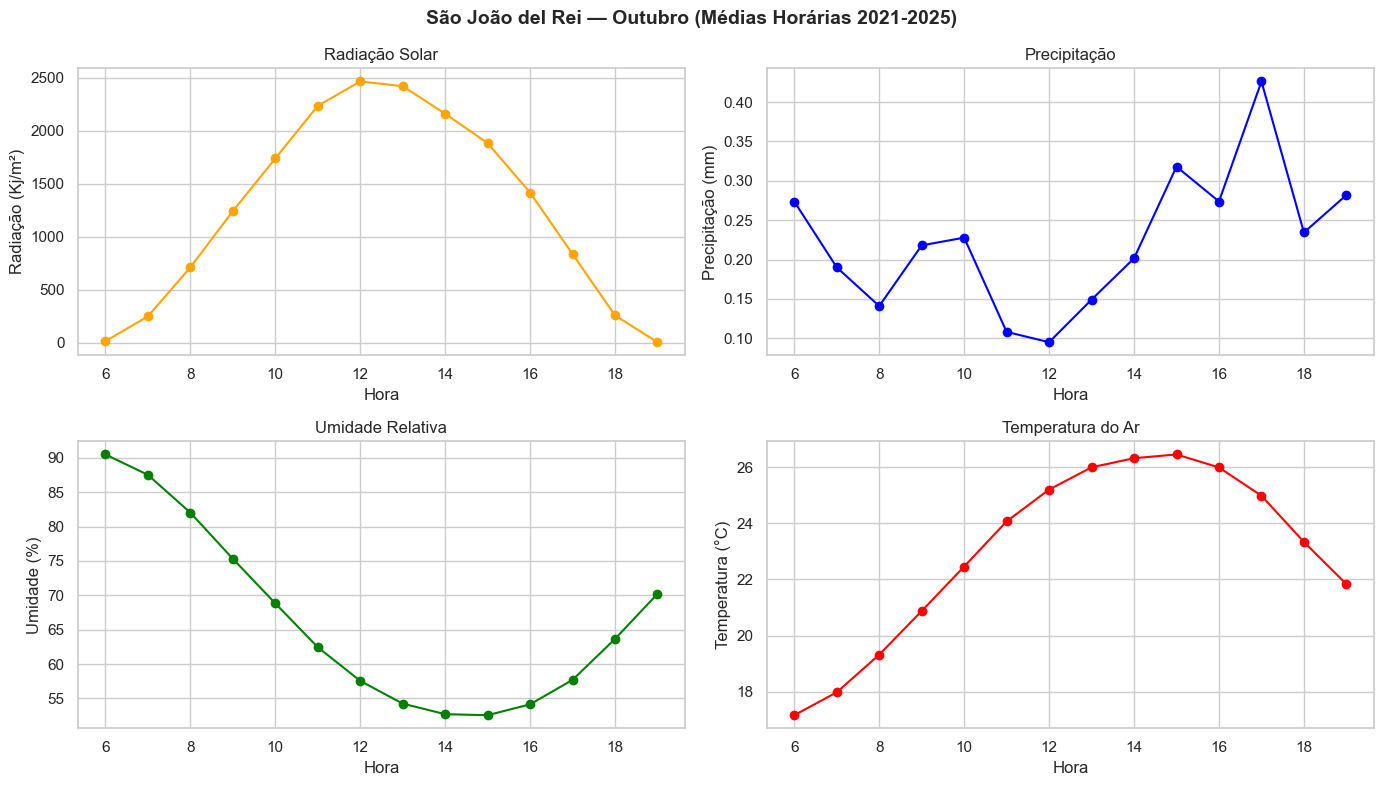

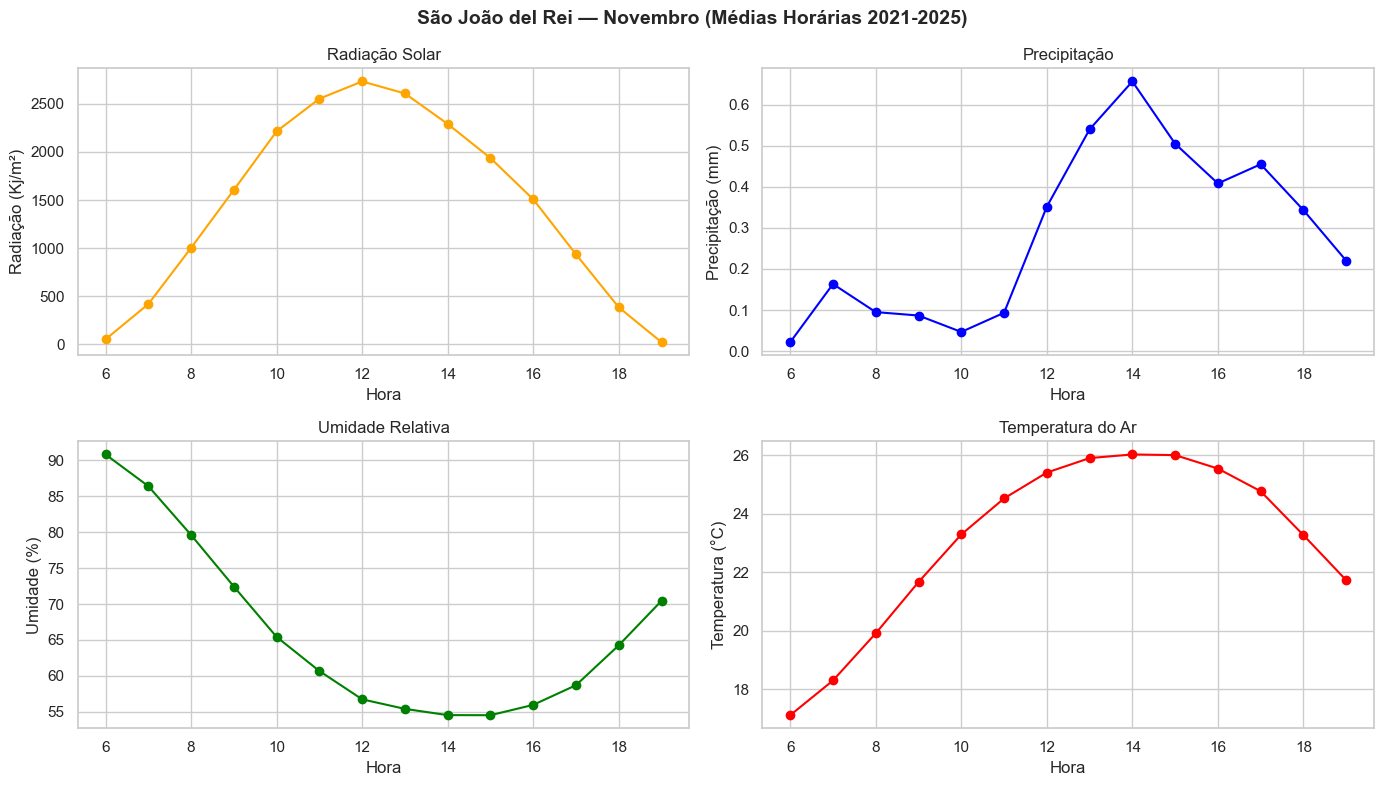

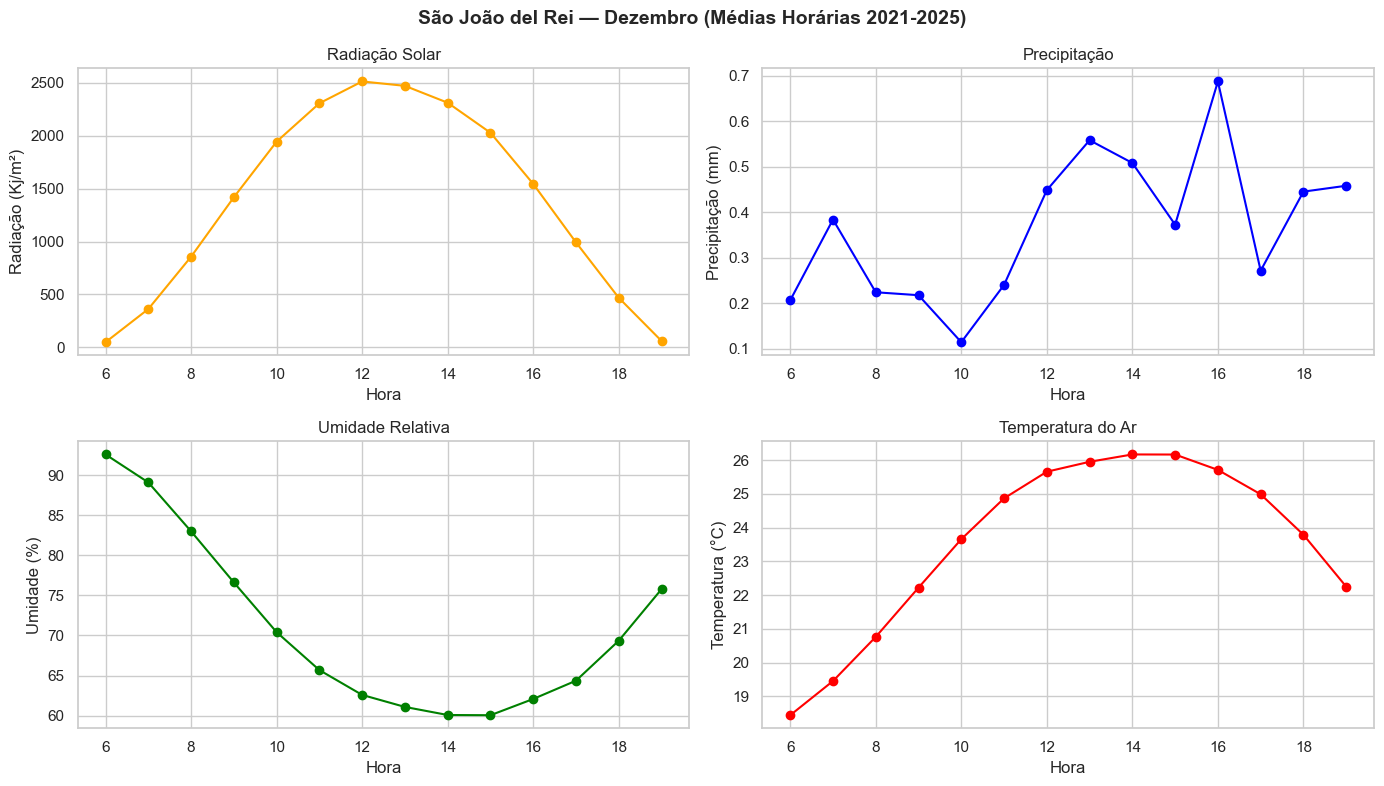

In [120]:
# Loop geral para a plotagem
for mes in range(1, 13):

    # Extraindo os dados de Média para cada hora
    radiacao    = [estatisticas_geral[estacao][mes][hora].loc['Média', 'Radiacao_Kj_m2']  for hora in horas_plot]
    precipitacao = [estatisticas_geral[estacao][mes][hora].loc['Média', 'Precipitacao_mm'] for hora in horas_plot]
    umidade     = [estatisticas_geral[estacao][mes][hora].loc['Média', 'Umidade_Rel_%']   for hora in horas_plot]
    temperatura = [estatisticas_geral[estacao][mes][hora].loc['Média', 'Temp_Ar_C']       for hora in horas_plot]

    # Configurando os gráficos
    fig, axs = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f'São João del Rei — {nomes_meses[mes]} (Médias Horárias 2021-2025)', fontsize=14, fontweight='bold')

    # Radiação
    axs[0, 0].plot(list(horas_plot), radiacao, color='orange', marker='o')
    axs[0, 0].set_title('Radiação Solar')
    axs[0, 0].set_xlabel('Hora')
    axs[0, 0].set_ylabel('Radiação (Kj/m²)') 
    axs[0, 0].grid(True)

    # Precipitação
    axs[0, 1].plot(list(horas_plot), precipitacao, color='blue', marker='o')
    axs[0, 1].set_title('Precipitação')
    axs[0, 1].set_xlabel('Hora')
    axs[0, 1].set_ylabel('Precipitação (mm)')
    axs[0, 1].grid(True)

    # Umidade
    axs[1, 0].plot(list(horas_plot), umidade, color='green', marker='o')
    axs[1, 0].set_title('Umidade Relativa')
    axs[1, 0].set_xlabel('Hora')
    axs[1, 0].set_ylabel('Umidade (%)')
    axs[1, 0].grid(True)

    # Temperatura
    axs[1, 1].plot(list(horas_plot), temperatura, color='red', marker='o')
    axs[1, 1].set_title('Temperatura do Ar')
    axs[1, 1].set_xlabel('Hora')
    axs[1, 1].set_ylabel('Temperatura (°C)')
    axs[1, 1].grid(True)

    plt.tight_layout()
    # Nome do arquivo com número e nome do mês
    #nome_arquivo = f'grafico_sao_joao_del_rei_{mes:02d}_{nomes_meses[mes]}.png'
    #plt.savefig(nome_arquivo, dpi=150)
    #plt.close()  # ← importante! Fecha a figura antes de criar a próxima
    
    plt.show()


><span style="color:green">São João del-Rei tem boa insolação durante o ano todo, com pico diário sempre entre 12h e 13h, atingindo valores de 2.500–2.700 kJ/m² nos meses mais favoráveis. Os meses de maior radiação são março, julho e agosto (picos acima de 2.700 kJ/m²), enquanto maio, junho e julho têm os dias mais curtos (sol sumindo antes das 18h), o que reduz um pouco o total diário.

><span style="color:green">A precipitação há uma diferença enorme entre a estação chuvosa (outubro a março) e a seca (abril a setembro). Janeiro, fevereiro, março, novembro e dezembro têm chuvas expressivas ao longo do dia, com médias horárias chegando a 0,7–1,2 mm/h especialmente no fim da tarde/noite. De junho a agosto, a precipitação horária é praticamente zero (valores na casa de 0,001–0,04 mm/h), sendo os meses ideais para atividades ao ar livre.

><span style="color:green">Já a temperatura e umidade seguem com padrão diário muito consistente ao longo do ano: umidade sempre alta pela manhã (85–95%) e caindo ao meio-dia (mínima de 38–60% dependendo do mês), depois subindo novamente ao entardecer. A temperatura segue a mesma lógica, partindo mais baixa às 6h e atingindo o pico entre 13h e 15h. Os valores absolutos variam por mês (verão mais quente, inverno com mínimas baixas), mas o ritmo diário é estável e previsível.

><span style="color:green">Em suma, julho e agosto são os meses ideais, com uma boa radiação, quase zero de chuva e umidade relativa mais baixa ao longo do dia. Setembro também é excelente, combinando o maior pico de radiação do ano com precipitação ainda baixa. O período de novembro a março é o mais desfavorável para quem busca dias secos e ensolarados, com chuvas pesadas concentradas no fim da tarde e à noite.

### *5.3.3 Plots de box plot de Radiação, Precipitação da estação desejada.*
<span style="color:green">
Este script carrega os dados brutos de uma estação meteorológica, filtra um mês específico
e gera box plots horários para Radiação Solar e Precipitação.


1. Definição dos parâmetros de interesse

- Define a estação: `MG-SAO_JOAO_DEL_REI-A514`
- Define as variáveis a plotar: `Precipitacao_mm` e `Radiacao_Kj_m2`
- Cria o dicionário `nomes_variaveis` mapeando cada coluna para:
  - Nome legível para o título do gráfico
  - Unidade de medida para o eixo Y
  - Cor de preenchimento das caixas

2. Carregamento dos dados brutos da estação

- Monta o caminho da pasta da estação usando `caminho_principal` e o sufixo `-Filtrada`
- Itera sobre os anos (2021–2025), carregando cada CSV com `;` como separador e `,` como decimal
- Imprime confirmação ou aviso de arquivo não encontrado para cada ano
- Concatena todos os anos em um único DataFrame `dados`

In [116]:
# Estação e mês de interesse para o box plot
estacao_interesse = 'MG-SAO_JOAO_DEL_REI-A514'

#Definindo as variáveis a serem plotadas
colunas = ['Precipitacao_mm', 'Radiacao_Kj_m2']

# Dicionário para mapear os nomes das variáveis para títulos e unidades
nomes_variaveis = {
    'Radiacao_Kj_m2':  ('Radiação Solar',    'Kj/m²', 'orange'),
    'Precipitacao_mm': ('Precipitação',       'mm',    'blue'),
}

<span style="color:green">
2. Carregamento dos dados brutos da estação

- Monta o caminho da pasta da estação usando `caminho_principal` e o sufixo `-Filtrada`
- Itera sobre os anos (2021–2025), carregando cada CSV com `;` como separador e `,` como decimal
- Imprime confirmação ou aviso de arquivo não encontrado para cada ano
- Concatena todos os anos em um único DataFrame `dados`

3. Pré-processamento dos dados

- Converte a coluna `Data` para o tipo `datetime`
- Subtrai 3 horas da coluna `Hora` para ajuste de fuso horário (UTC → Brasília)
- Cria a coluna `Mes` extraindo o número do mês

In [117]:
# Carregando os dados brutos da estação de interesse
pasta           = f'{estacao_interesse}-Filtrada'
caminho_estacao = os.path.join(caminho_principal, pasta)

# Carrega os arquivos dos 5 anos da estação
lista_dfs = []
for ano in anos:
    arquivo = os.path.join(caminho_estacao, f'{estacao_interesse}-{ano}_Filtrada.csv')
    if os.path.exists(arquivo):
        df_ano = pd.read_csv(arquivo, sep=';', decimal=',')
        lista_dfs.append(df_ano)
        print(f'{ano} carregado!')
    else:
        print(f'{ano} não encontrado!')

# Concatenando os anos em um único DataFrame
dados = pd.concat(lista_dfs, ignore_index=True)

# Pré-processamento
dados["Data"] = pd.to_datetime(dados["Data"])
dados["Hora"] = dados["Hora"] - 3
dados["Mes"]  = dados["Data"].dt.month

# Separando os dados brutos por hora para o mês de interesse
dados_mes = dados[dados["Mes"] == mes_interesse]

2021 carregado!
2022 carregado!
2023 carregado!
2024 carregado!
2025 carregado!


<span style="color:green">
4. Filtragem por mês e separação por hora

- Define os mêses de análise (Janeiro e Setembro)
- Filtra o DataFrame mantendo apenas as linhas do mês de interesse (`dados_mes`)
- Cria o dicionário `dados_brutos[hora]` onde cada entrada contém todos os valores brutos das colunas selecionadas para aquela hora (sem agregação — dados crus para o box plot)

5. Configuração da figura

- Cria uma figura com **1 linha × 2 colunas** de subgráficos (`figsize=(15, 6)`)
- Define o limite superior do eixo Y da precipitação como **50% acima da média**, evitando que outliers extremos distorçam a escala
- Define o título geral da figura com a estação, mês e período

6. Plotagem dos Box Plots

- Itera sobre os dois eixos e variáveis simultaneamente com `zip`
- Para cada variável, monta uma lista com os valores brutos de cada hora (arrays sem `NaN`)
- Cria o box plot com as seguintes configurações:

| Parâmetro       | Valor / Efeito                              |
|-----------------|---------------------------------------------|
| `patch_artist`  | Permite colorir as caixas                   |
| `showmeans`     | Exibe a média como losango preto (`◆`)      |
| `showfliers`    | `False` — oculta outliers extremos          |
| `medianprops`   | Linha da mediana em preto com espessura 2   |
| `widths`        | Largura de 0,6 para cada caixa              |

- Preenche cada caixa com a cor definida no dicionário `nomes_variaveis`, com transparência de 50% (`alpha=0.5`)

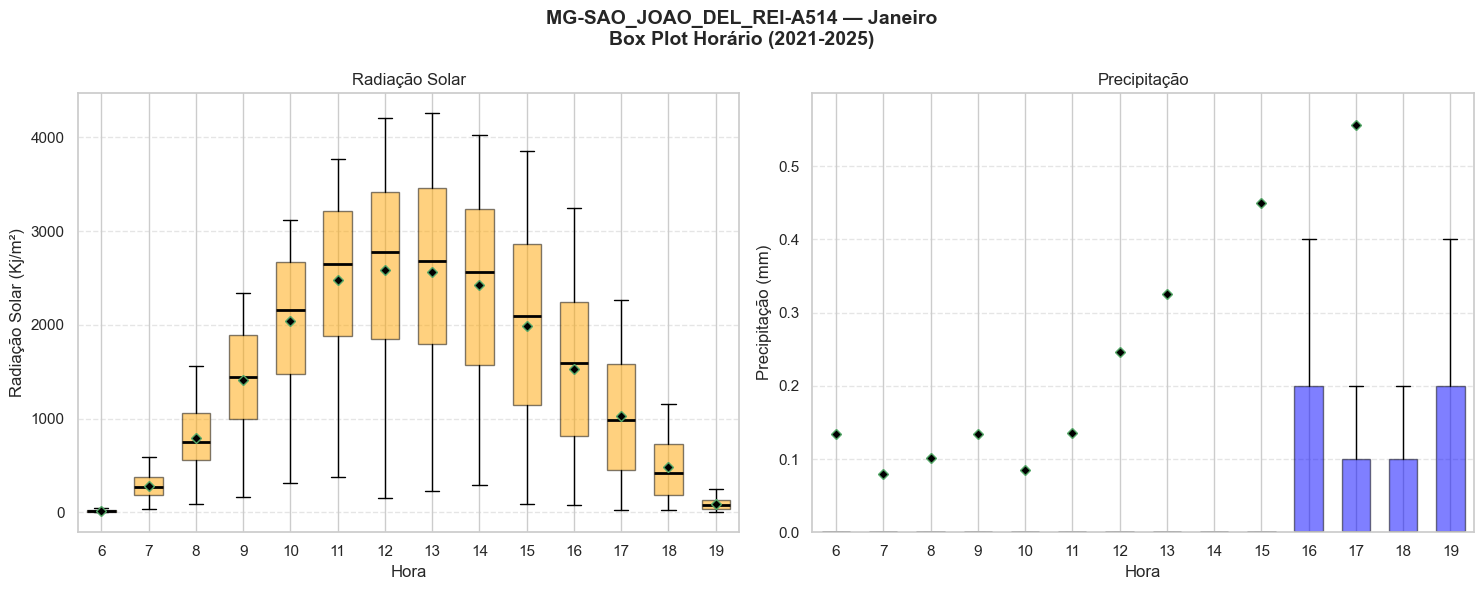

Box plot salvo: boxplot_MG-SAO_JOAO_DEL_REI-A51401Janeiro.png


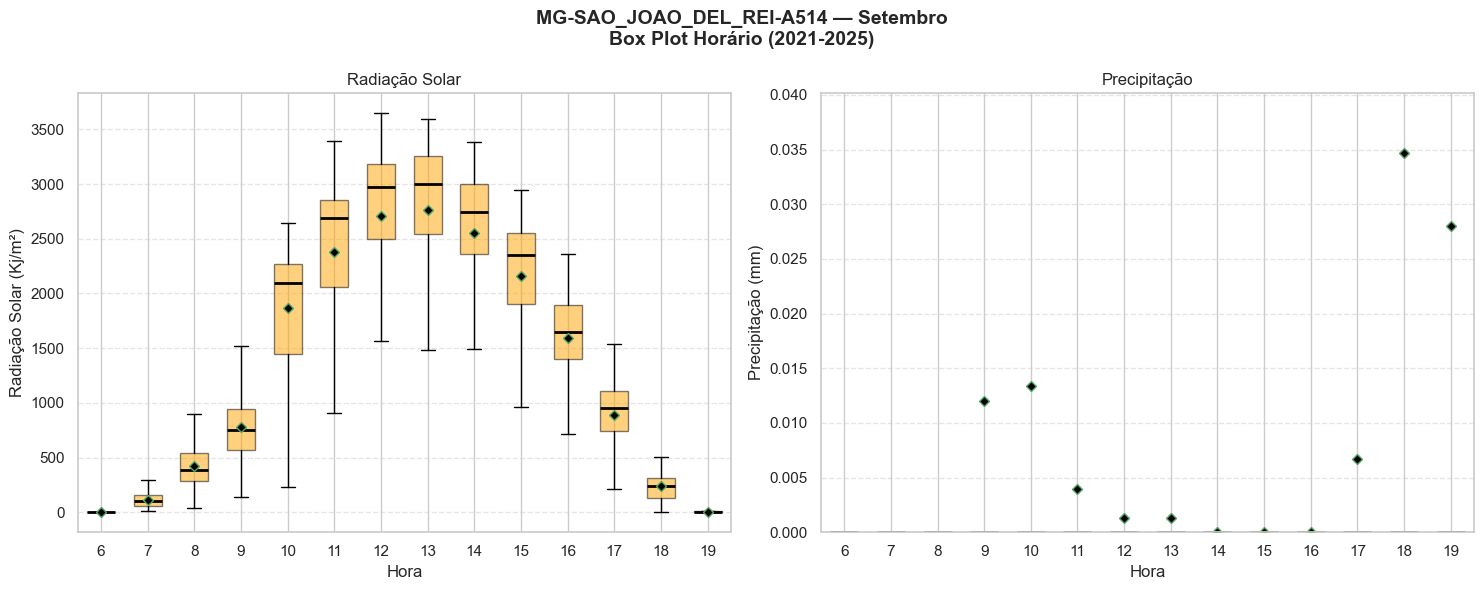

Box plot salvo: boxplot_MG-SAO_JOAO_DEL_REI-A51409Setembro.png


In [118]:
for mes_interesse in [1, 9]:

    # Separando os dados brutos por hora para o mês de interesse
    dados_mes = dados[dados["Mes"] == mes_interesse]

    dados_brutos = {}
    for hora in horas_plot:
        dados_brutos[hora] = dados_mes[dados_mes["Hora"] == hora][colunas]

    # Plotando o Box Plot
    fig, axs = plt.subplots(1, 2, figsize=(15, 6))
    ymax_precipitacao = np.mean(dados_mes['Precipitacao_mm']) * 1.5
    axs[1].set_ylim(0, ymax_precipitacao)
    fig.suptitle(
        f'{estacao_interesse} — {nomes_meses[mes_interesse]}\nBox Plot Horário (2021-2025)',
        fontsize=14, fontweight='bold'
    )

    for ax, var in zip(axs.flatten(), nomes_variaveis.keys()):
        nome, unidade, cor = nomes_variaveis[var]

        dados_por_hora = [
            dados_brutos[hora][var].dropna().values
            for hora in horas_plot
        ]

        bp = ax.boxplot(
            dados_por_hora,
            positions    = list(horas_plot),
            widths       = 0.6,
            patch_artist = True,
            showmeans    = True,
            showfliers   = False,
            meanprops    = dict(marker='D', markerfacecolor='black', markersize=5),
            medianprops  = dict(color='black', linewidth=2)
        )

        for patch in bp['boxes']:
            patch.set_facecolor(cor)
            patch.set_alpha(0.5)

        ax.set_title(nome)
        ax.set_xlabel('Hora')
        ax.set_ylabel(f'{nome} ({unidade})')
        ax.set_xticks(list(horas_plot))
        ax.grid(True, axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    nome_arquivo = f'boxplot_{estacao_interesse}{mes_interesse:02d}{nomes_meses[mes_interesse]}.png'
    plt.savefig(nome_arquivo, dpi=150)
    plt.show()
    print(f'Box plot salvo: {nome_arquivo}')


><span style="color:green">Como podemos observar, janeiro, mês de verão tropical, apresenta valores de radiação solar com grande amplitude estatística ao longo de todos os horários diurnos. Os bigodes superiores ultrapassam 4.000 kJ/m² nos horários de pico, indicando dias de insolação intensa. Contudo, os bigodes inferiores também se estendem amplamente para baixo, evidenciando que, em um mesmo horário, a radiação pode variar de valores máximos a valores próximos de zero. Essa instabilidade é explicada pela alta frequência de chuvas convectivas características do verão tropical, concentradas predominantemente no período da tarde, a partir das 14h, quando os box plots de precipitação passam a apresentar distribuições estatisticamente relevantes, com medianas acima do segundo quartil. A nebulosidade associada a esses eventos é o principal agente de interrupção da insolação, tornando a geração fotovoltaica neste mês elevada em potencial máximo, porém imprevisível e pouco confiável.

><span style="color:green">Já setembro, inserido na estação seca, apresenta um perfil bem diferente. Embora os picos máximos de radiação sejam ligeiramente inferiores aos de janeiro, a característica mais relevante do mês está na consistência dos valores. Os bigodes inferiores dos box plots se mantêm elevados na janela das 11h às 15h, sustentando uma potência mínima em torno de 1.000 kJ/m², mesmo nos dias menos favoráveis. A amplitude interquartílica reduzida confirma que os valores de radiação são mais homogêneos entre os anos analisados. No que diz respeito à precipitação, o gráfico de setembro não apresenta boxes formados em nenhum horário, apenas pontos isolados de magnitude entre 0,001 e 0,035 mm/h, valores entre 30 e 50 vezes menores do que os registrados em janeiro. A ausência de chuvas elimina o principal fator de perturbação da insolação, conferindo ao mês uma segurança estatística que janeiro não é capaz de oferecer.

><span style="color:green">A comparação entre os dois meses demonstra que, para fins de aproveitamento de energia solar, a confiabilidade de geração não é determinada apenas pelo potencial máximo de radiação, mas sobretudo pela sua previsibilidade. Janeiro apresenta teto alto, porém instável, enquanto setembro apresenta valores ligeiramente menores, porém consistentes e protegidos pela ausência de precipitação. Para o dimensionamento de sistemas fotovoltaicos, setembro configura-se como o mês de referência mais seguro, enquanto janeiro exige maior capacidade de armazenamento e tolerância à variabilidade para que o sistema opere com eficiência satisfatória.

## 6. Perspectivas para Modelagem Preditiva (Machine Learning)

A estruturação, a filtragem e a análise exploratória conduzidos nas etapas anteriores compõem a fundação clássica de um *pipeline* de dados. O artefato final gerado (a base diária limpa e agrupada) está perfeitamente apto para alimentar algoritmos de *Machine Learning*. 

Nesta seção, discutimos como essa base se traduziria em um problema formal de aprendizado de máquina e os desafios inerentes a esse processo.

### 6.1 Formulação do Problema de Aprendizado

Dada a natureza contínua e temporal das variáveis meteorológicas, a aplicação primária desta base de dados estaria associada à **Regressão** estruturada como um problema de **Série Temporal**.
* **O Problema de Regressão:** O objetivo principal seria prever a grandeza contínua de **Horas de Sol Pleno (HSP)** ou a **Radiação Global** para dias ou semanas futuras, utilizando variáveis exógenas (Temperatura, Umidade, Precipitação) e a própria radiação passada como *features* (preditores).
* **Formulação Alternativa (Classificação):** De forma secundária, o problema poderia ser modelado como **Classificação Binária ou Multiclasse**. Por exemplo, poderíamos criar uma variável alvo categorizando os dias em "Geração Ótima", "Geração Intermediária" e "Geração Crítica" (baseado em limiares de HSP), treinando o modelo para classificar a viabilidade energética do dia seguinte visando o despacho de baterias ou o acionamento de termelétricas no SEP.

### 6.2 Desafios Previstos na Etapa de Modelagem

A transição da análise estatística para a modelagem preditiva em dados climáticos impõe desafios singulares:

1. **Autocorrelação e Sazonalidade:** O modelo precisará lidar com múltiplos ciclos sobrepostos (a variação diária de temperatura e a sazonalidade anual do inverno/verão). Algoritmos que não capturam memória sequencial podem ter desempenho insatisfatório.
2. **Não-linearidade Física:** Variáveis como a temperatura têm uma relação não-linear com a eficiência fotovoltaica (o excesso de calor diminui a potência do painel). O algoritmo precisará ser capaz de mapear essas dinâmicas físicas complexas.

### 6.3 O Comportamento do Erro: Viés, Variância e Ajustes

Na busca pelo modelo preditivo ideal para a geração solar, o diagnóstico de erros se manifestaria da seguinte forma:

* **Subajuste:** Ocorreria se utilizássemos um algoritmo excessivamente simples (como uma Regressão Linear Simples). O modelo seria incapaz de capturar a "curvatura" da sazonalidade anual ou o impacto abrupto das chuvas de verão, resultando em previsões generalistas e achatadas (errando sistematicamente tanto no treino quanto no teste).
* **Sobreajuste:** Ocorreria se utilizássemos um modelo altamente complexo. O modelo acabaria "decorando" os dados meteorológico dos anos de treino e perderia a capacidade de generalização.
* **Viés-Variância:** O desafio central da modelagem neste contexto será encontrar a fronteira de complexidade ideal. O algoritmo deve ser flexível o suficiente para aprender o perfil macroclimático da região e as interações térmicas (reduzindo o viés), mas restrito o bastante para ignorar os dados estocásticos e as anomalias diárias imprevisíveis (reduzindo a variância).